# Sales Data Exploration
A exploration of all sales dataset to study its' general properties.

## 1. Load data and check general info

In [2]:
import pandas as pd

df_train = pd.read_csv('../data/train.csv', index_col='id')

df_train['date'] = pd.to_datetime(df_train['date'])

display(df_train)

,date,store_nbr,family,sales,onpromotion
id,,,,,
0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,2013-01-01,1,BABY CARE,0.000,0
2,2013-01-01,1,BEAUTY,0.000,0
3,2013-01-01,1,BEVERAGES,0.000,0
4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...
3000883,2017-08-15,9,POULTRY,438.133,0
3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,2017-08-15,9,PRODUCE,2419.729,148


In [3]:
# General info
print(df_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3000888 entries, 0 to 3000887
Data columns (total 5 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   store_nbr    int64         
 2   family       object        
 3   sales        float64       
 4   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 137.4+ MB
None


In [4]:
display(df_train.describe())

,date,store_nbr,sales,onpromotion
count,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [5]:
# Check for null values
null_percent = df_train.isnull().sum() * 100
print(null_percent)

date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


No null values.

In [6]:
# Check categorical columns' unique values
print("Amount of and unique values in 'store_nbr':")
print(df_train['store_nbr'].nunique())

display(df_train.groupby('store_nbr').agg({'sales': ['sum', 'mean']}).reset_index().sort_values(by=('sales', 'sum'), ascending=False))

Amount of and unique values in 'store_nbr':
54


store_nbr         sales             
                       sum         mean
43        44  6.208755e+07  1117.245254
44        45  5.449801e+07   980.673908
46        47  5.094831e+07   916.798209
2          3  5.048191e+07   908.405495
48        49  4.342010e+07   781.330450
45        46  4.189606e+07   753.905962
47        48  3.593313e+07   646.604950
50        51  3.291149e+07   592.231511
7          8  3.049429e+07   548.734739
49        50  2.865302e+07   515.601753
10        11  2.832556e+07   509.709179
6          7  2.695205e+07   484.993334
8          9  2.640944e+07   475.229271
5          6  2.518368e+07   453.172101
23        24  2.376773e+07   427.692592
1          2  2.155739e+07   387.918172
38        39  2.025219e+07   364.431594
36        37  1.997064e+07   359.365069
26        27  1.918802e+07   345.282181
3          4  1.890970e+07   340.273886
37        38  1.886000e+07   339.379530
39        40  1.839576e+07   331.025650
27        28  1.838315e+07   330.798871
16        17  1.803097e+07   324.461406
30        31  1.774687e+07   319.349181
33        34  1.709073e+07   307.542182
42        43  1.639169e+07   294.963151
4          5  1.559240e+07   280.580231
35        36  1.532243e+07   275.722146
40        41  1.499104e+07   269.758856
32        33  1.417850e+07   255.137503
0          1  1.414501e+07   254.534889
17        18  1.325938e+07   238.598137
18        19  1.304951e+07   234.821670
19        20  1.292095e+07   232.508360
22        23  1.165138e+07   209.662792
14        15  1.145127e+07   206.061866
24        25  1.142100e+07   205.517129
13        14  1.138792e+07   204.921881
52        53  1.121617e+07   201.831269
53        54  1.105748e+07   198.975799
15        16  1.098641e+07   197.696908
11        12  1.065922e+07   191.809148
12        13  1.052305e+07   189.358775
28        29  9.725158e+06   175.001038
9         10  9.613906e+06   172.999096
20        21  9.255506e+06   166.549808
41        42  8.945768e+06   160.976173
25        26  7.755122e+06   139.550887
34        35  7.676679e+06   138.139340
29        30  7.382074e+06   132.838006
31        32  5.951796e+06   107.100626
21        22  4.090202e+06    73.601845
51        52  2.696170e+06    48.516694

In [7]:
print("Amount of and unique values in 'family':")
print(df_train['family'].nunique())

display(df_train.groupby('family').agg({'sales': ['sum', 'mean']}).reset_index().sort_values(by=('sales', 'sum'), ascending=False))

Amount of and unique values in 'family':
33


family         sales             
                                         sum         mean
12                   GROCERY I  3.434627e+08  3776.972100
3                    BEVERAGES  2.169545e+08  2385.793151
30                     PRODUCE  1.227047e+08  1349.352123
7                     CLEANING  9.752129e+07  1072.416744
8                        DAIRY  6.448771e+07   709.154889
5                 BREAD/BAKERY  4.213395e+07   463.336254
28                     POULTRY  3.187600e+07   350.532292
24                       MEATS  3.108647e+07   341.849965
25               PERSONAL CARE  2.459205e+07   270.432513
9                         DELI  2.411032e+07   265.135067
18                   HOME CARE  1.602274e+07   176.198029
10                        EGGS  1.558830e+07   171.420516
11                FROZEN FOODS  1.407389e+07   154.766954
29              PREPARED FOODS  8.799895e+06    96.770202
22            LIQUOR,WINE,BEER  7.746640e+06    85.187824
32                     SEAFOOD  2.015432e+06    22.163190
13                  GROCERY II  1.962767e+06    21.584048
15          HOME AND KITCHEN I  1.861491e+06    20.470342
16         HOME AND KITCHEN II  1.520670e+06    16.722420
6                  CELEBRATION  7.611770e+05     8.370469
21                    LINGERIE  6.531140e+05     7.182128
19                  LADIESWEAR  6.511590e+05     7.160629
27     PLAYERS AND ELECTRONICS  5.626080e+05     6.186857
0                   AUTOMOTIVE  5.548220e+05     6.101236
20             LAWN AND GARDEN  5.488420e+05     6.035475
26                PET SUPPLIES  3.565840e+05     3.921263
2                       BEAUTY  3.378930e+05     3.715723
31  SCHOOL AND OFFICE SUPPLIES  2.693160e+05     2.961599
23                   MAGAZINES  2.663590e+05     2.929082
14                    HARDWARE  1.034700e+05     1.137833
17             HOME APPLIANCES  4.160100e+04     0.457476
1                    BABY CARE  1.005100e+04     0.110528
4                        BOOKS  6.438000e+03     0.070797

In [8]:
# Check unique granularities (store_nbr, family)
# and their sales sums

unique_granularities = df_train.groupby(['store_nbr', 'family']).agg({'sales': ['sum', 'mean']}).reset_index()
print(f"Amount of unique (store_nbr, family) granularities: {len(unique_granularities)}")
display(unique_granularities.sort_values(by=('sales', 'sum'), ascending=False))

Amount of unique (store_nbr, family) granularities: 1782


store_nbr      family         sales             
                                     sum         mean
1431        44   GROCERY I  1.638606e+07  9730.436483
1464        45   GROCERY I  1.634975e+07  9708.878439
1530        47   GROCERY I  1.551453e+07  9212.902904
1497        46   GROCERY I  1.434226e+07  8516.782660
1422        44   BEVERAGES  1.341786e+07  7967.849762
...        ...         ...           ...          ...
367         12       BOOKS  0.000000e+00     0.000000
565         18       BOOKS  0.000000e+00     0.000000
1420        44   BABY CARE  0.000000e+00     0.000000
1042        32  LADIESWEAR  0.000000e+00     0.000000
397         13   BABY CARE  0.000000e+00     0.000000

[1782 rows x 4 columns]

# 2. Sales distribution

## 2. 1. Full time series

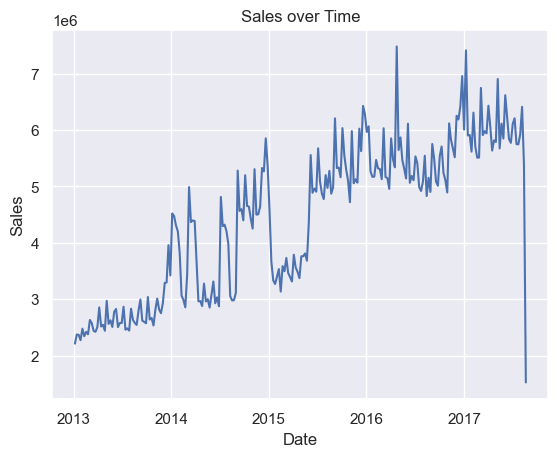

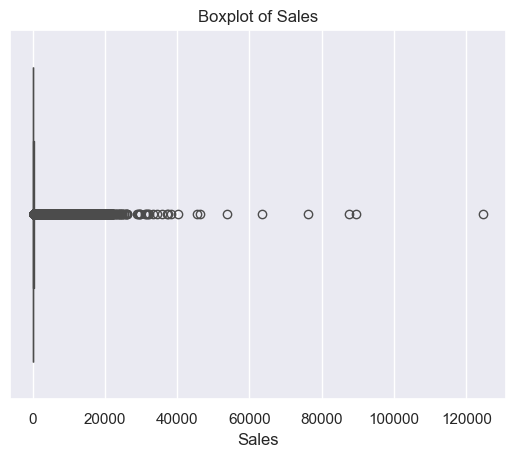

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Boxplot
sns.set_theme()

# Group by week to see overall trend
df_train_weekly = (
     df_train
    .resample('W', on='date')
    .sum()
    .reset_index()
    .sort_values(by='date')
)

ax = sns.lineplot(
    data=df_train_weekly,
    x='date',
    y='sales'
)

df_train = df_train.groupby(['store_nbr', 'family','date']).sum().reset_index().sort_values(by='date')

ax.set_title('Sales over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')

plt.show()

ax = sns.boxplot(
    data=df_train,
    x='sales'
)

ax.set_title('Boxplot of Sales')
ax.set_xlabel('Sales')

plt.show()

We can seek a peak in the data around April, 2016. This was caused by the magnitude 7.8 earthquake that struck Ecuador on April 16, 2016, which led to people making an effort to donate water and other first need products, impacting the supermarkets' sales for several weeks.

The data is very heavily right-skewed. Let's check its' skewness (and also kurtosis).

In [10]:
print(f"Skew: {df_train['sales'].skew()}")
print(f"Kurtosis: {df_train['sales'].kurtosis()}")

Skew: 7.35875781888264
Kurtosis: 154.5620923696478


The skeweness we see may be caused because in some days/stores there was much more sales for a given family than in other days. Let's plot the distribution with a log transform and by granularity.

## 2. 2. Log-transformed sales' distribution

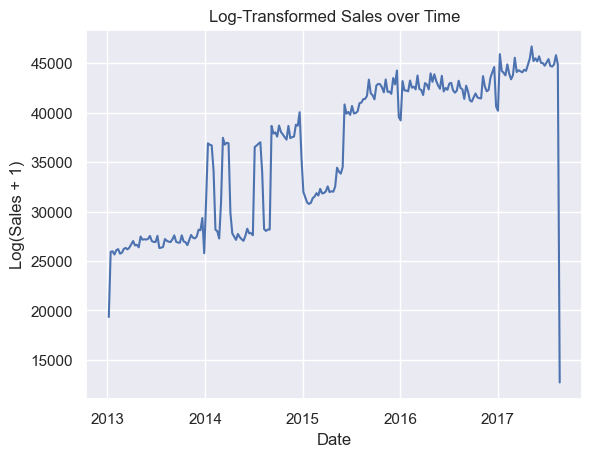

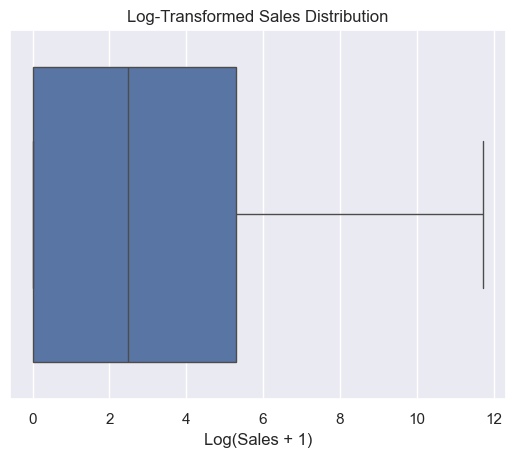

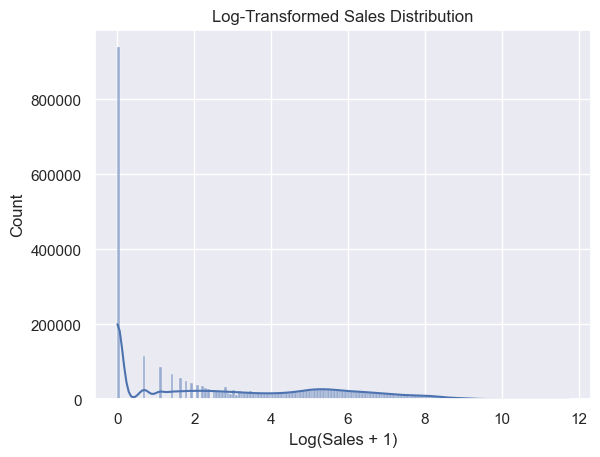

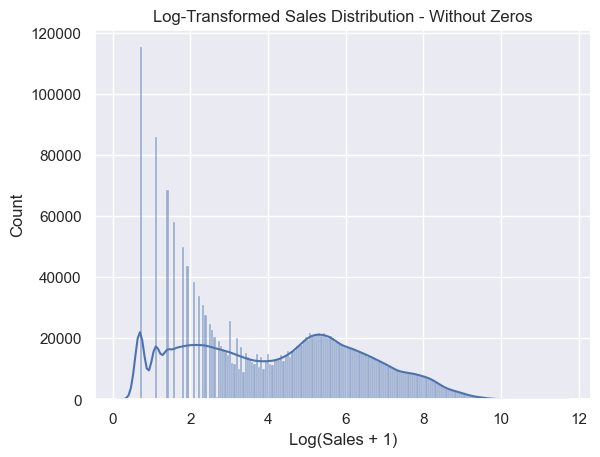

Skew: 0.40829549860804987
Kurtosis: -1.1497087167738185


In [11]:
df_train['sales_log'] = np.log1p(df_train['sales'])

ax = sns.lineplot(
    data=df_train.resample('W', on='date').sum().reset_index().sort_values(by='date'),
    x='date',
    y='sales_log'
)

ax.set_title('Log-Transformed Sales over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Log(Sales + 1)')
plt.show()

ax = sns.boxplot(
    data=df_train,
    x='sales_log'
)

ax.set_title('Log-Transformed Sales Distribution')
ax.set_xlabel('Log(Sales + 1)')

plt.show() 

ax = sns.histplot(
    data=df_train,
    x='sales_log',
    kde=True
)

ax.set_title('Log-Transformed Sales Distribution')
ax.set_xlabel('Log(Sales + 1)')
plt.show()

# Let's visualize also without zeros
ax = sns.histplot(
    data=df_train[df_train['sales'] > 0],
    x='sales_log',
    kde=True
)

ax.set_title('Log-Transformed Sales Distribution - Without Zeros')
ax.set_xlabel('Log(Sales + 1)')
plt.show()

print(f"Skew: {df_train['sales_log'].skew()}")
print(f"Kurtosis: {df_train['sales_log'].kurtosis()}")

The distribution becomes much more balanced. This may be applied for further analysis and models estimations.

Now, let's check the type of the distribution's curve for each granularity and check if any of them is different of what we saw.

## 2. 3. Distribution by granularity

In [12]:
from scipy.stats import skew, kurtosis

# skewness and kurtosis of sales by (store_nbr, family)
df_distribution_by_granularity = (
     df_train
    .groupby(['store_nbr', 'family'])['sales']
    .agg(
        skew=lambda x: skew(x),
        kurtosis=lambda x: kurtosis(x),
        total_sales='sum',
        mean_sales='mean'
    )
    .reset_index()
)

left_skewed_distributions = df_distribution_by_granularity[df_distribution_by_granularity['skew'] < 0]

print("Distribution by granularity (store_nbr, family)")
display(df_distribution_by_granularity.sort_values(by='total_sales', ascending=False))
print("\n\nLeft-skewed distributions:")
display(left_skewed_distributions.sort_values(by='total_sales', ascending=False))

Distribution by granularity (store_nbr, family)


,store_nbr,family,skew,kurtosis,total_sales,mean_sales
1431,44,GROCERY I,1.862983,9.824374,1.638606e+07,9730.436483
1464,45,GROCERY I,4.237987,55.341743,1.634975e+07,9708.878439
1530,47,GROCERY I,0.863869,0.699728,1.551453e+07,9212.902904
1497,46,GROCERY I,1.135376,1.221743,1.434226e+07,8516.782660
1422,44,BEVERAGES,0.916229,0.684657,1.341786e+07,7967.849762
...,...,...,...,...,...,...
367,12,BOOKS,NaN,NaN,0.000000e+00,0.000000
565,18,BOOKS,NaN,NaN,0.000000e+00,0.000000
1420,44,BABY CARE,NaN,NaN,0.000000e+00,0.000000
1042,32,LADIESWEAR,NaN,NaN,0.000000e+00,0.000000




Left-skewed distributions:


,store_nbr,family,skew,kurtosis,total_sales,mean_sales
96,3,PRODUCE,-0.076872,-1.571254,8.613316e+06,5114.795792
1614,49,PRODUCE,-0.021257,-1.506992,8.017967e+06,4761.263210
228,7,PRODUCE,-0.084430,-1.486742,5.576834e+06,3311.659265
1647,50,PRODUCE,-0.002016,-1.371955,2.428159e+06,1441.899711
206,7,DAIRY,-0.421858,-0.343003,2.063308e+06,1225.242280
94,3,POULTRY,-0.094185,-0.527037,1.905239e+06,1131.376791
766,24,CLEANING,-1.795701,4.213232,1.869705e+06,1110.276128
767,24,DAIRY,-0.764599,1.121234,1.807146e+06,1073.127078
162,5,PRODUCE,-0.004027,-1.281556,1.653582e+06,981.937208
1196,37,DAIRY,-0.214450,2.121002,1.489783e+06,884.669240


Let's check skew and kurtosis distributions.

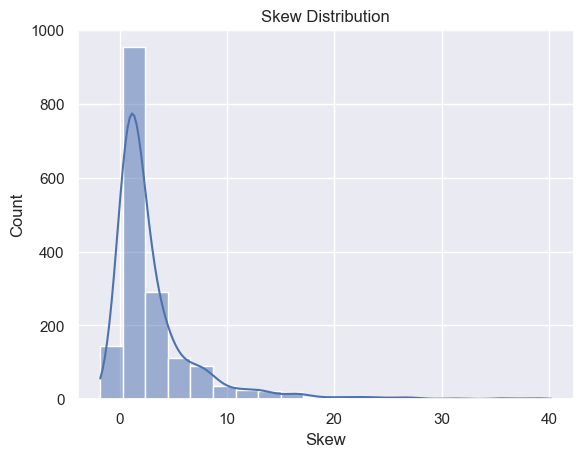

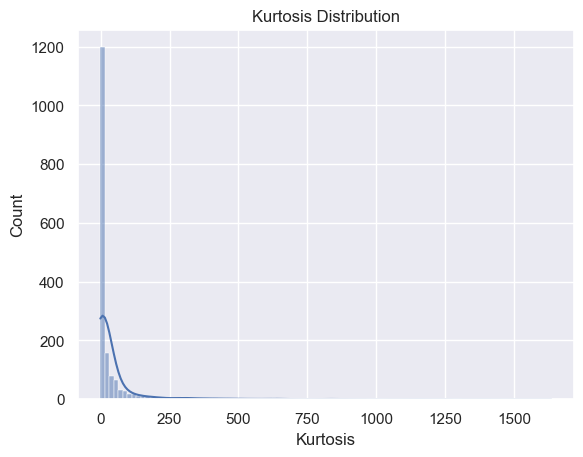

In [29]:
ax = sns.histplot(
    data=df_distribution_by_granularity,
    x='skew',
    kde=True,
    bins=20
)

ax.set_title('Skew Distribution')
ax.set_xlabel('Skew')
ax.set_ylabel('Count')

plt.show()

ax = sns.histplot(
    data=df_distribution_by_granularity,
    x='kurtosis',
    kde=True,
    bins=100
)

ax.set_title('Kurtosis Distribution')
ax.set_xlabel('Kurtosis')
ax.set_ylabel('Count')

plt.show()

Some common skew and kurtosis values and some extreme ones. Let's look at the left-skewed distribution (the ones with more sales).

In [13]:
print("Sales by granularity's descriptive statistics:")
display(unique_granularities.describe())

print(f"Amount of left-skewed distributions: {len(left_skewed_distributions)}\
 ({(len(left_skewed_distributions) / len(unique_granularities)) * 100:.2f}%)")

q3 = unique_granularities['sales'].quantile(0.75)['mean']

left_skewed_distributions_above_q3 = left_skewed_distributions[left_skewed_distributions['mean_sales'] > q3]

print(f"\n\nLeft-skewed distributions above 75th percentile: ({len(left_skewed_distributions_above_q3)}):")
display(left_skewed_distributions_above_q3.sort_values(by='mean_sales', ascending=False))

Sales by granularity's descriptive statistics:


store_nbr         sales             
                             sum         mean
count  1782.000000  1.782000e+03  1782.000000
mean     27.500000  6.024944e+05   357.775749
std      15.590159  1.619762e+06   961.853944
min       1.000000  0.000000e+00     0.000000
25%      14.000000  4.868000e+03     2.890736
50%      27.500000  3.336400e+04    19.812350
75%      41.000000  3.721838e+05   221.011728
max      54.000000  1.638606e+07  9730.436483

Amount of left-skewed distributions: 53 (2.97%)


Left-skewed distributions above 75th percentile: (37):


,store_nbr,family,skew,kurtosis,total_sales,mean_sales
96,3,PRODUCE,-0.076872,-1.571254,8.613316e+06,5114.795792
1614,49,PRODUCE,-0.021257,-1.506992,8.017967e+06,4761.263210
228,7,PRODUCE,-0.084430,-1.486742,5.576834e+06,3311.659265
1647,50,PRODUCE,-0.002016,-1.371955,2.428159e+06,1441.899711
206,7,DAIRY,-0.421858,-0.343003,2.063308e+06,1225.242280
94,3,POULTRY,-0.094185,-0.527037,1.905239e+06,1131.376791
766,24,CLEANING,-1.795701,4.213232,1.869705e+06,1110.276128
767,24,DAIRY,-0.764599,1.121234,1.807146e+06,1073.127078
162,5,PRODUCE,-0.004027,-1.281556,1.653582e+06,981.937208
1196,37,DAIRY,-0.214450,2.121002,1.489783e+06,884.669240



Store Number: 1, Family: BREAD/BAKERY, Skewness: -0.5646689651836405, Mean Sales: 338.4751828165083


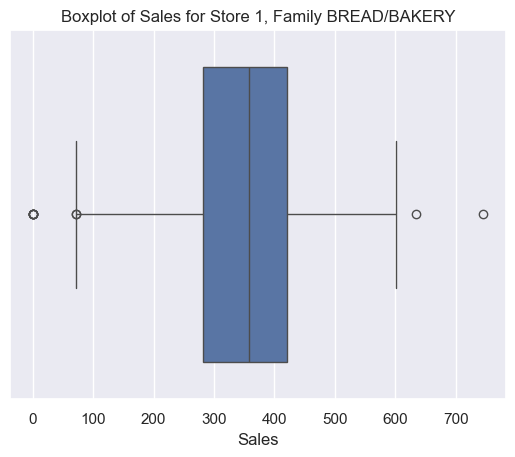

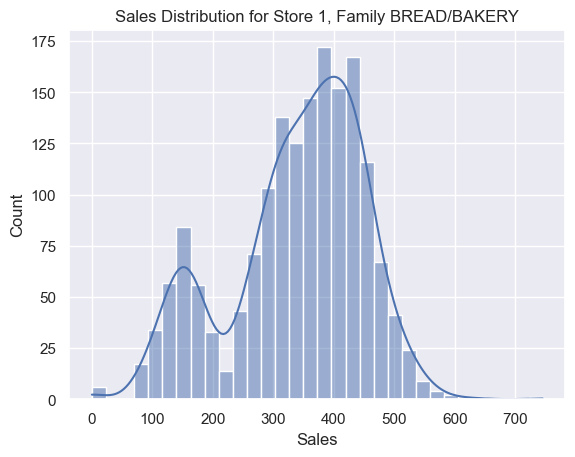


Store Number: 1, Family: CLEANING, Skewness: -0.5320587619480279, Mean Sales: 640.4542755344418


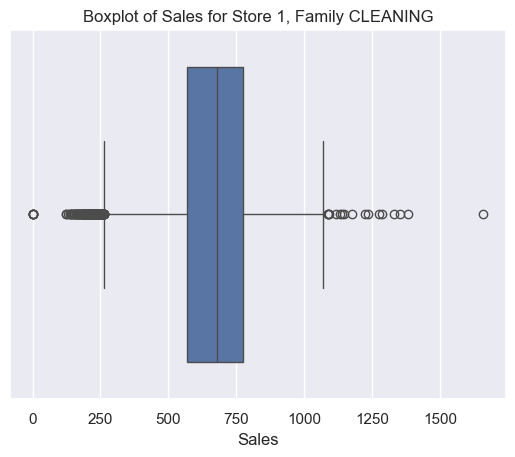

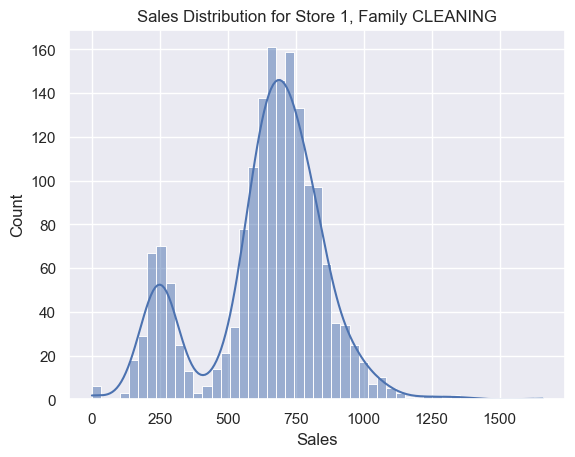


Store Number: 1, Family: DAIRY, Skewness: -0.37027640245092797, Mean Sales: 626.1009501187649


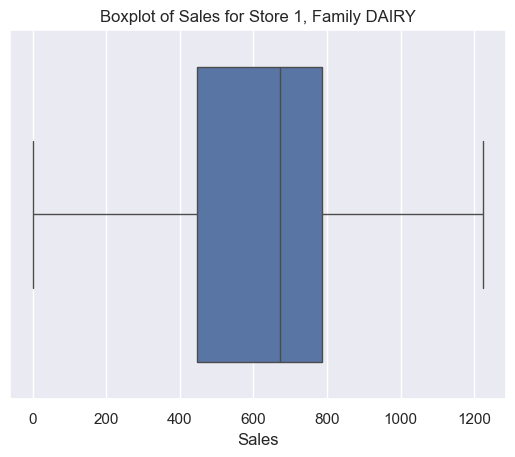

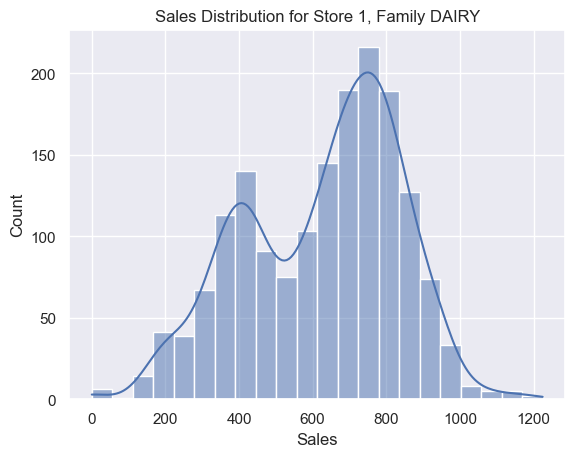


Store Number: 1, Family: DELI, Skewness: -0.28166158258520124, Mean Sales: 122.94363306769596


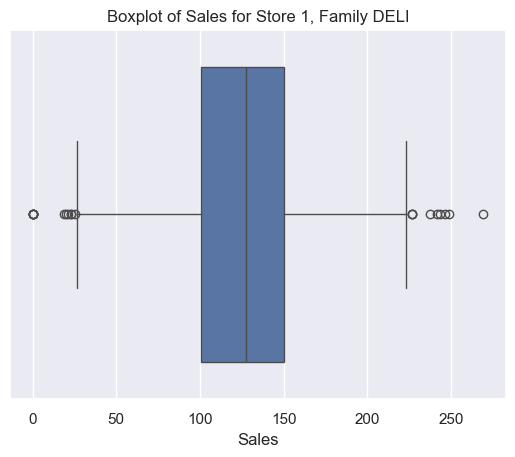

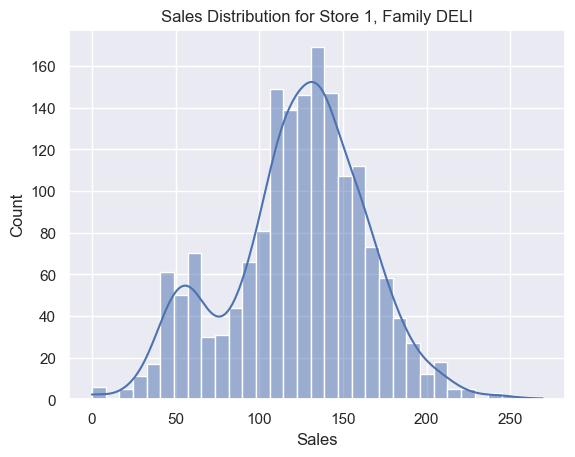


Store Number: 1, Family: EGGS, Skewness: -0.6976506046290771, Mean Sales: 140.44299287410925


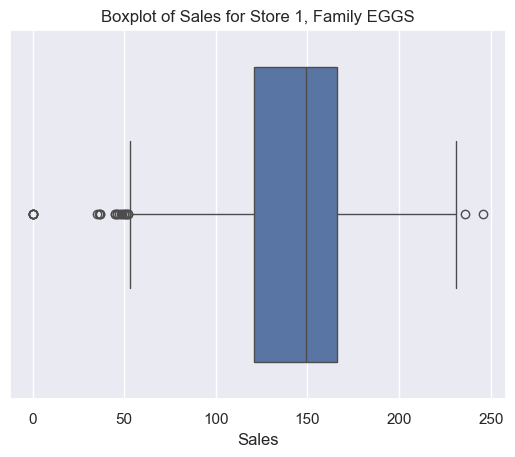

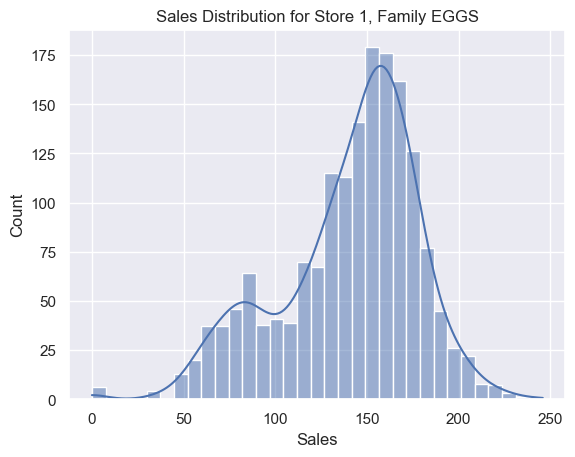


Store Number: 2, Family: POULTRY, Skewness: -0.031305666599911096, Mean Sales: 486.60359160391926


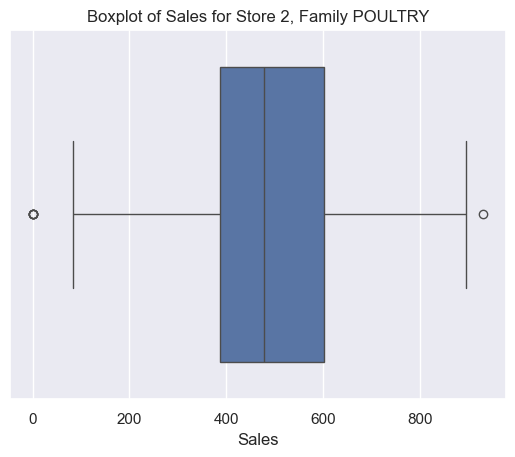

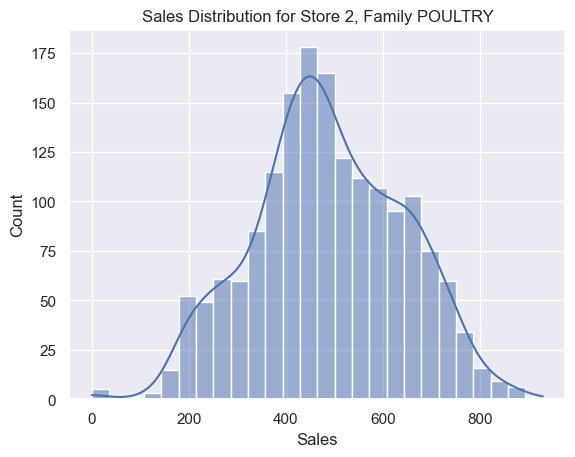


Store Number: 3, Family: POULTRY, Skewness: -0.0941846499226406, Mean Sales: 1131.3767907422803


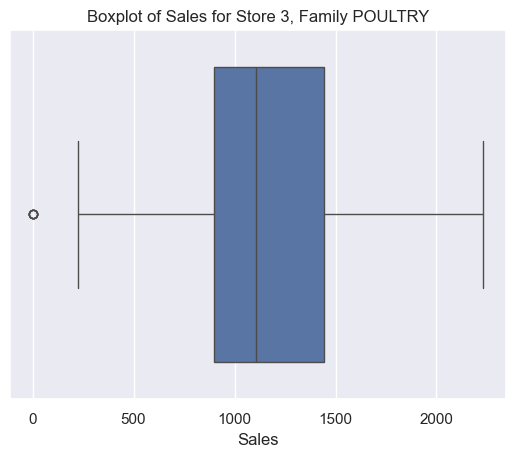

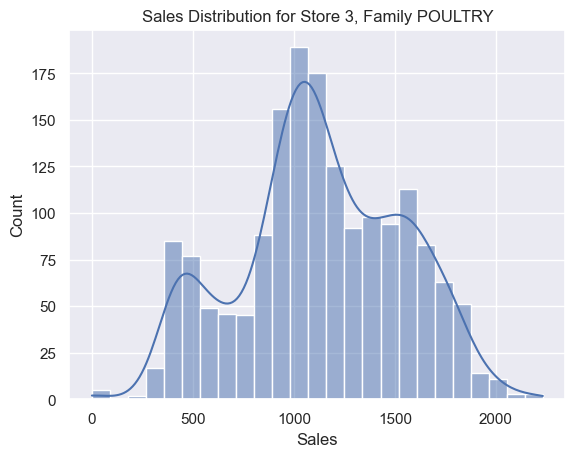


Store Number: 3, Family: PRODUCE, Skewness: -0.07687158634799307, Mean Sales: 5114.795791805225


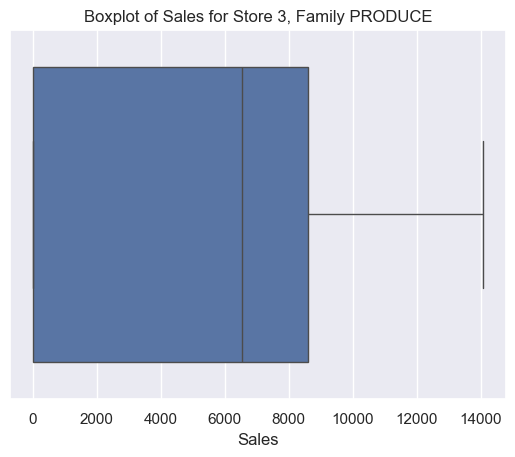

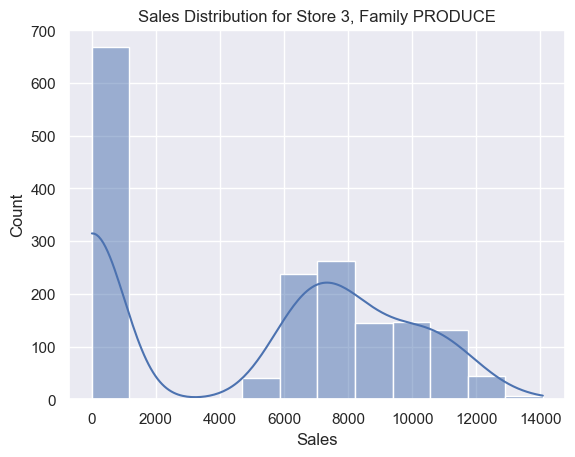


Store Number: 5, Family: PRODUCE, Skewness: -0.004027254720435962, Mean Sales: 981.9372082304038


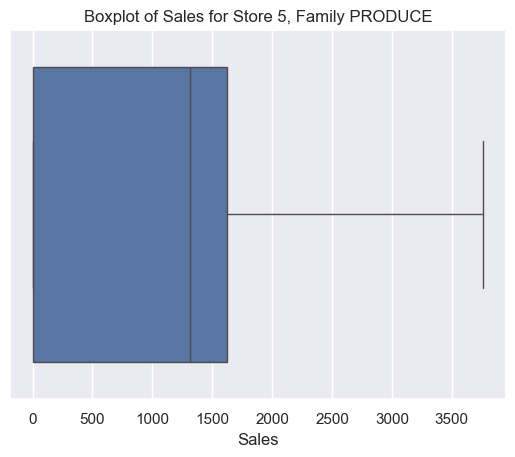

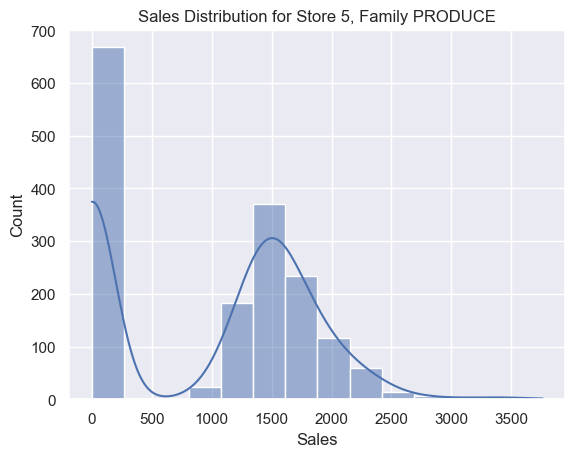


Store Number: 7, Family: DAIRY, Skewness: -0.42185807782880286, Mean Sales: 1225.2422802850356


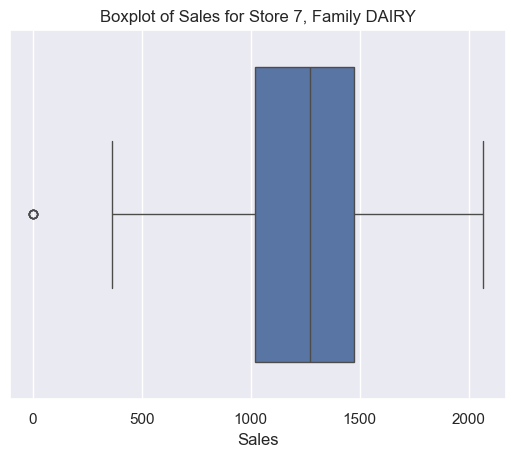

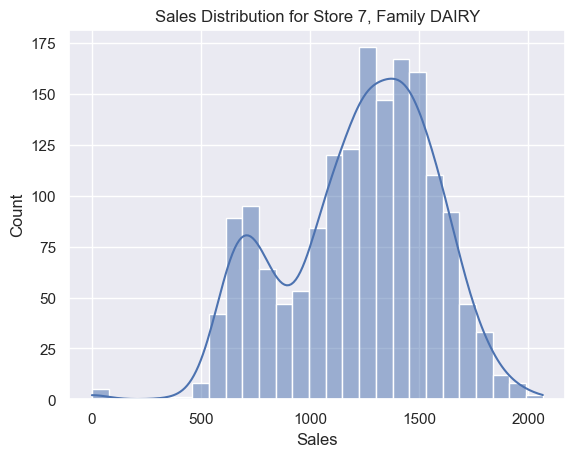


Store Number: 7, Family: EGGS, Skewness: -0.5761764572204321, Mean Sales: 284.90498812351547


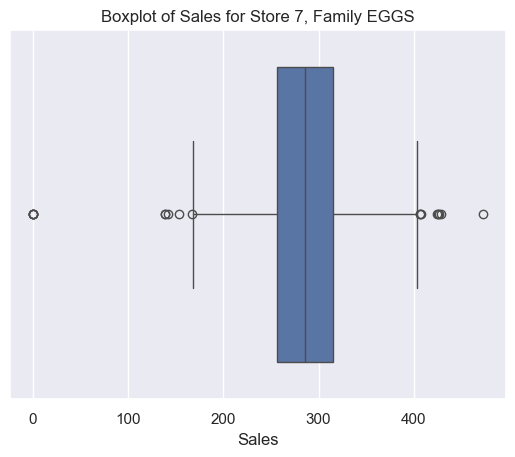

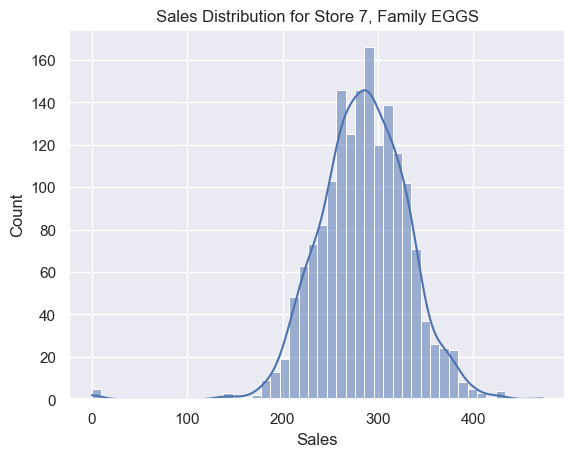


Store Number: 7, Family: POULTRY, Skewness: -0.5051977690025844, Mean Sales: 604.8893720427553


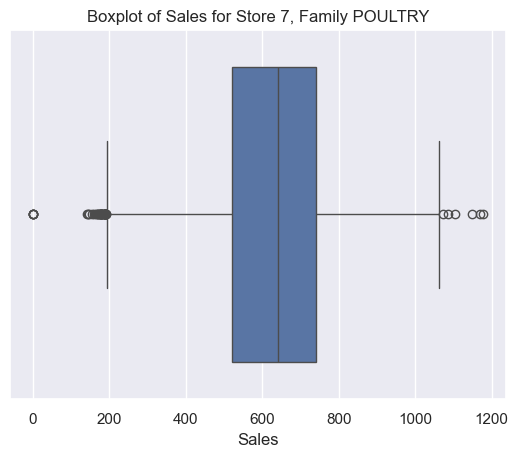

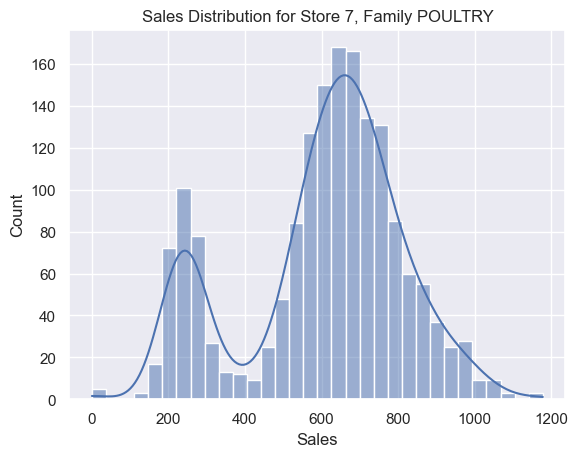


Store Number: 7, Family: PREPARED FOODS, Skewness: -0.15258747022103175, Mean Sales: 179.4110635095012


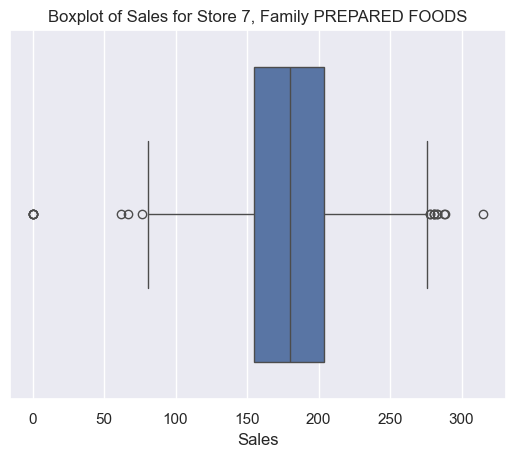

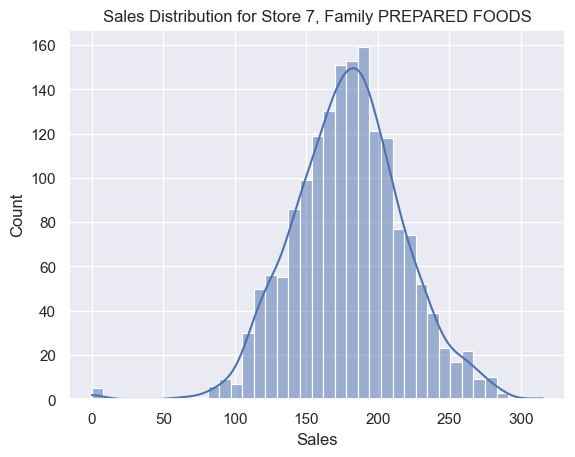


Store Number: 7, Family: PRODUCE, Skewness: -0.08443027467093167, Mean Sales: 3311.6592648456053


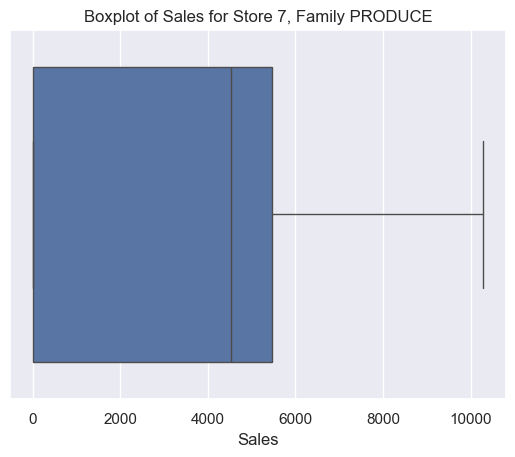

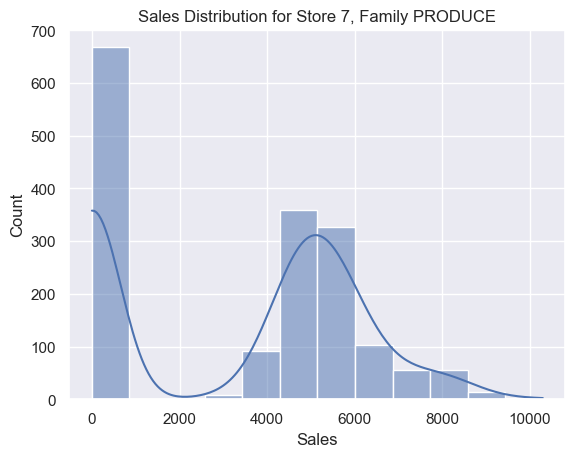


Store Number: 8, Family: POULTRY, Skewness: -0.12271956331633034, Mean Sales: 598.6586910332542


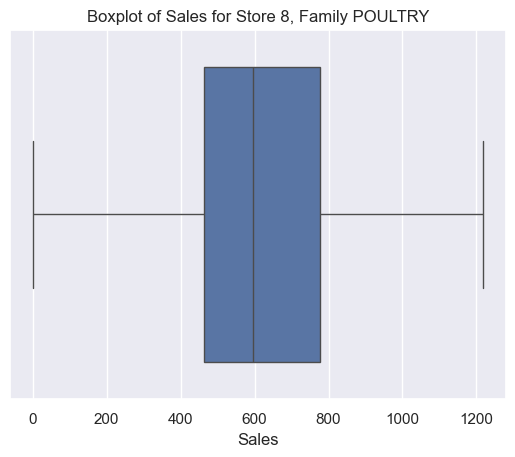

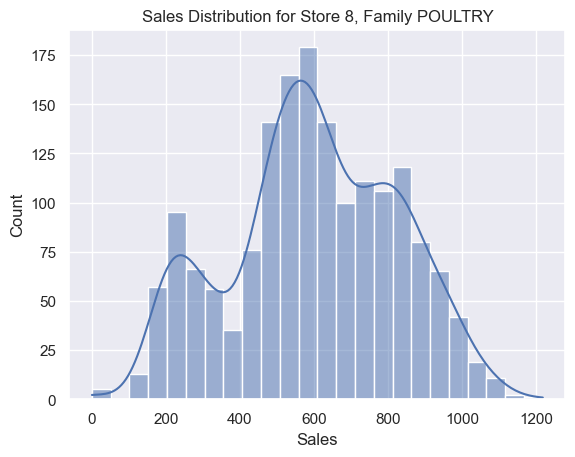


Store Number: 12, Family: DAIRY, Skewness: -0.12452726382796145, Mean Sales: 335.396674584323


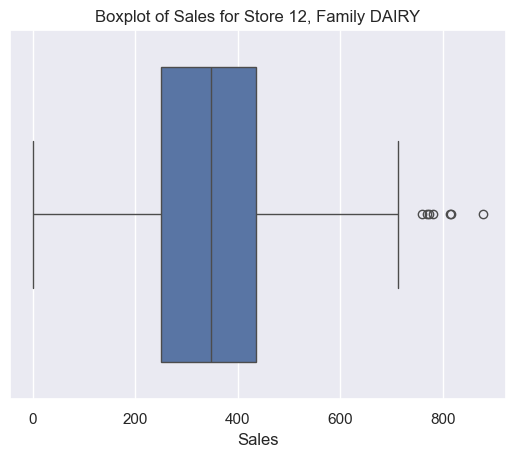

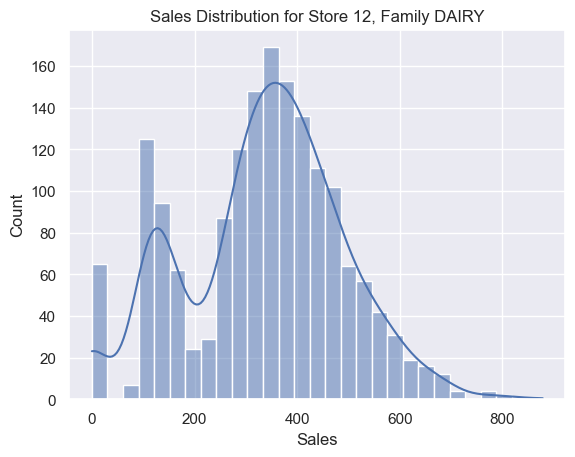


Store Number: 12, Family: DELI, Skewness: -0.11465240611552209, Mean Sales: 196.5665083135392


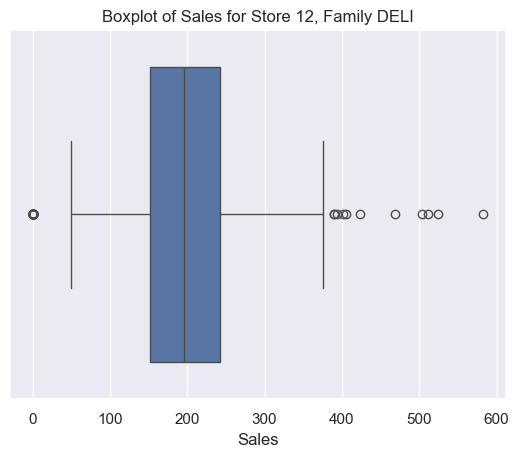

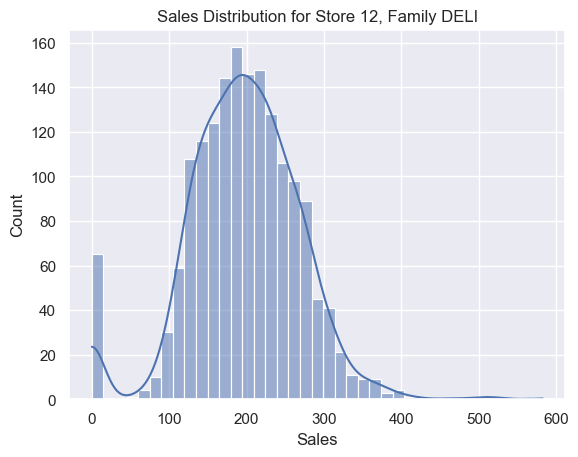


Store Number: 12, Family: PRODUCE, Skewness: -0.1402057543217992, Mean Sales: 203.11468900831355


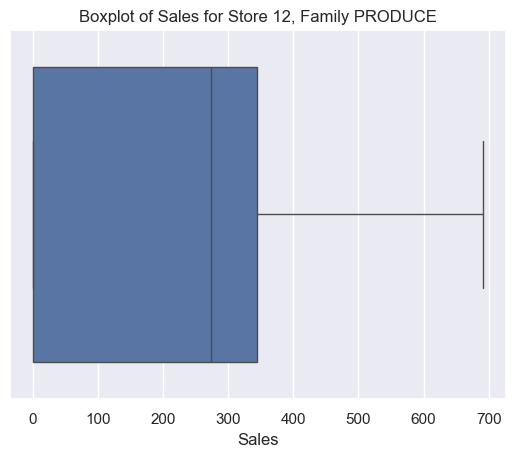

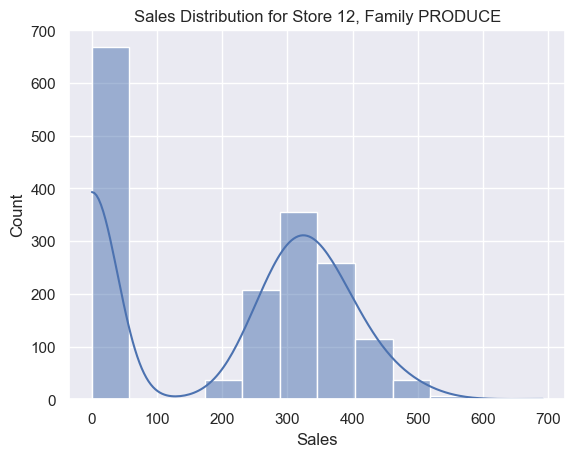


Store Number: 14, Family: BREAD/BAKERY, Skewness: -0.14043647176495952, Mean Sales: 191.74049881235155


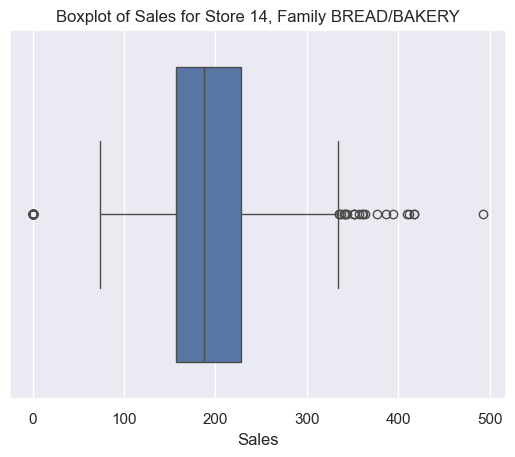

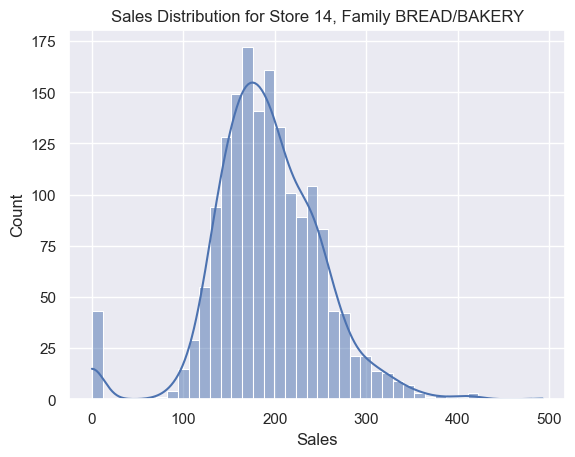


Store Number: 14, Family: DAIRY, Skewness: -0.24542176039406224, Mean Sales: 351.76543942992873


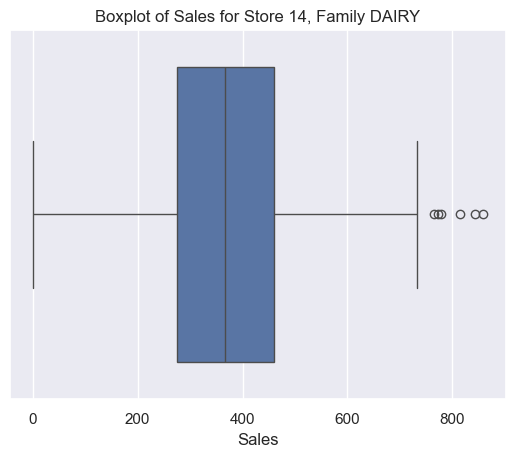

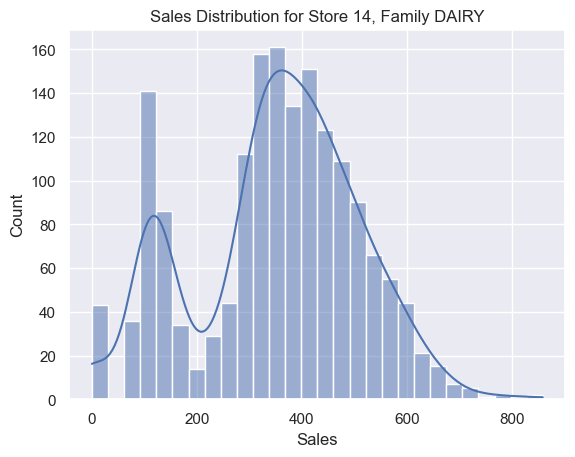


Store Number: 15, Family: DAIRY, Skewness: -0.3381766401742346, Mean Sales: 302.41805225653206


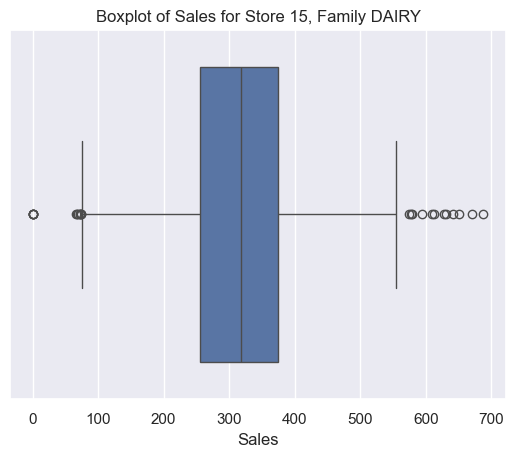

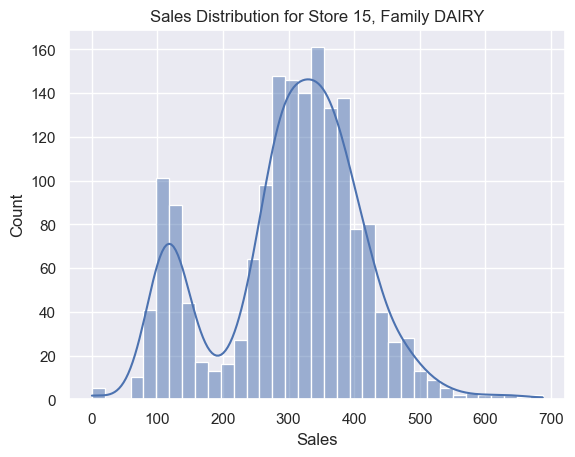


Store Number: 15, Family: HOME CARE, Skewness: -0.1278789215838976, Mean Sales: 146.92102137767222


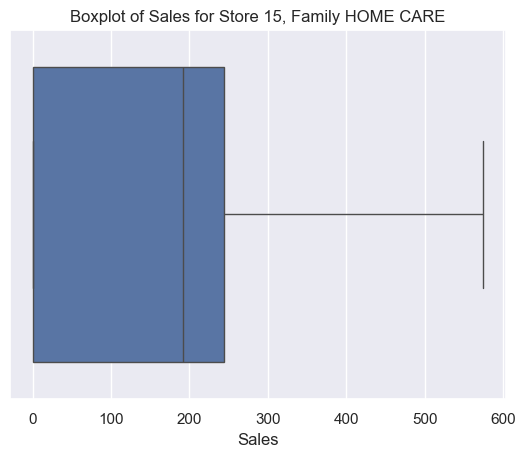

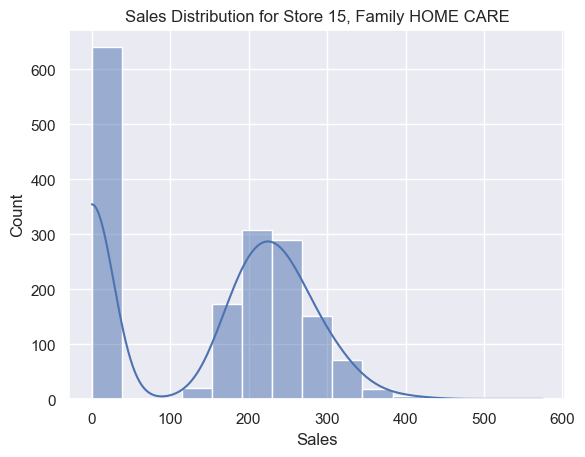


Store Number: 18, Family: BREAD/BAKERY, Skewness: -1.0601047176064007, Mean Sales: 658.993874703088


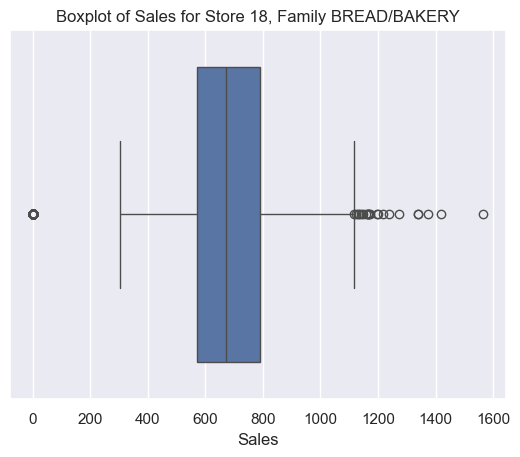

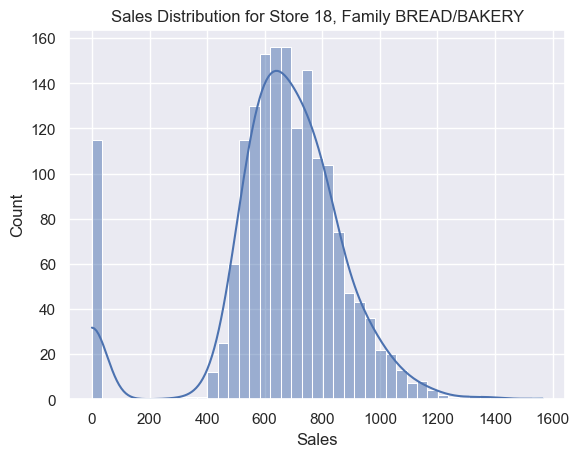


Store Number: 23, Family: BREAD/BAKERY, Skewness: -0.0017537503253841297, Mean Sales: 273.6696128562945


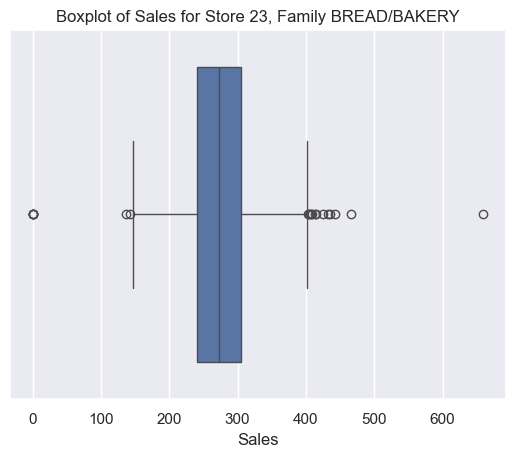

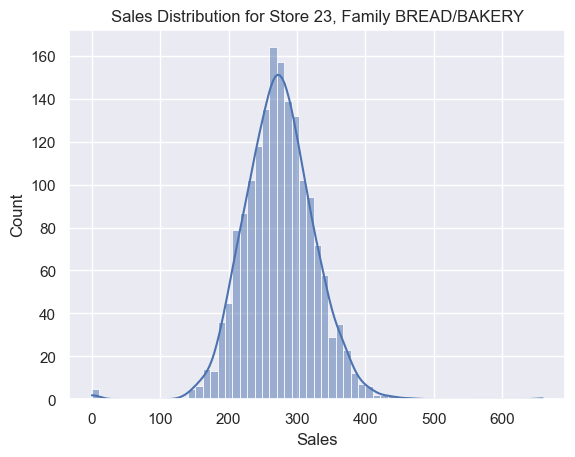


Store Number: 23, Family: HOME CARE, Skewness: -0.09724920124545873, Mean Sales: 86.77256532066508


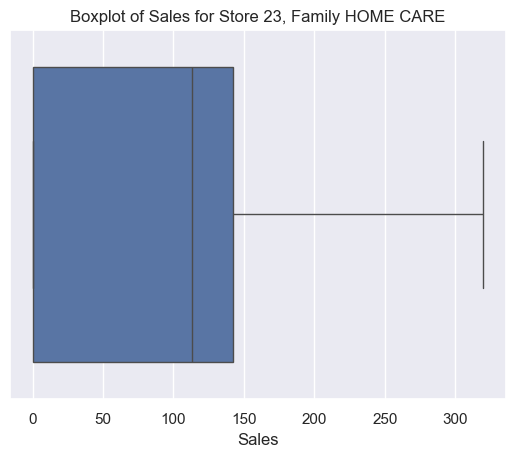

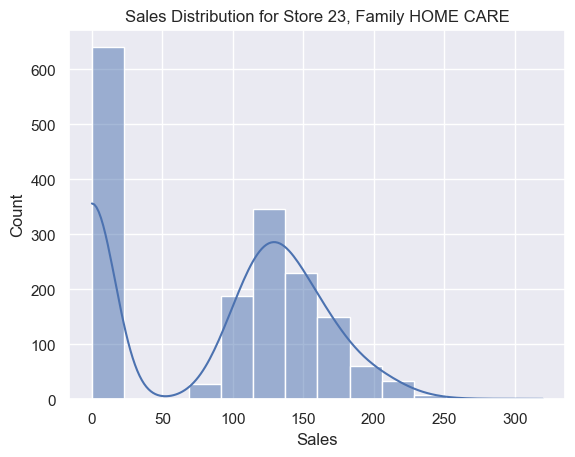


Store Number: 23, Family: POULTRY, Skewness: -0.03125348931555018, Mean Sales: 296.54476877553446


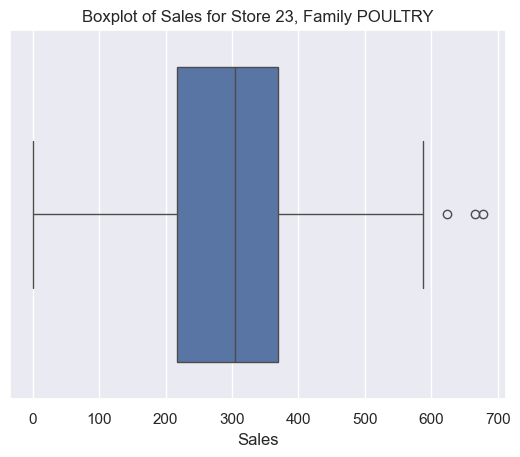

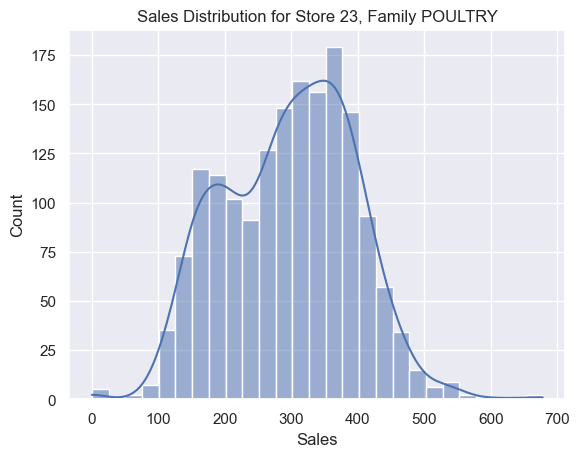


Store Number: 23, Family: PRODUCE, Skewness: -0.17311572302168934, Mean Sales: 791.3259654988123


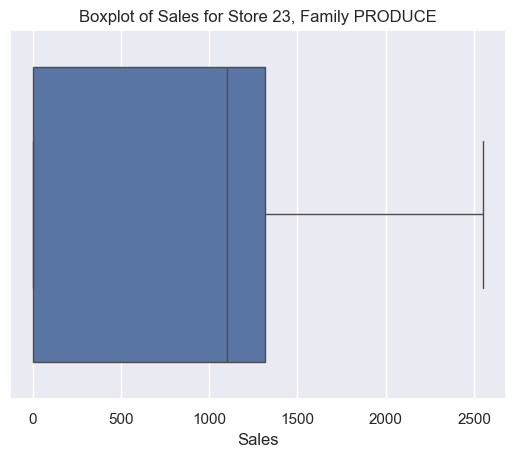

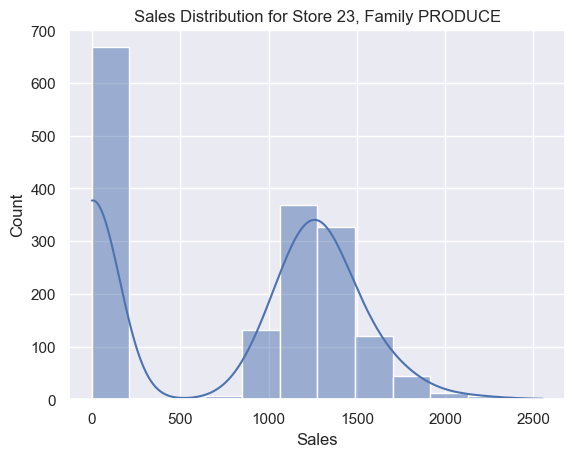


Store Number: 24, Family: BREAD/BAKERY, Skewness: -1.573444528621999, Mean Sales: 691.8998408551068


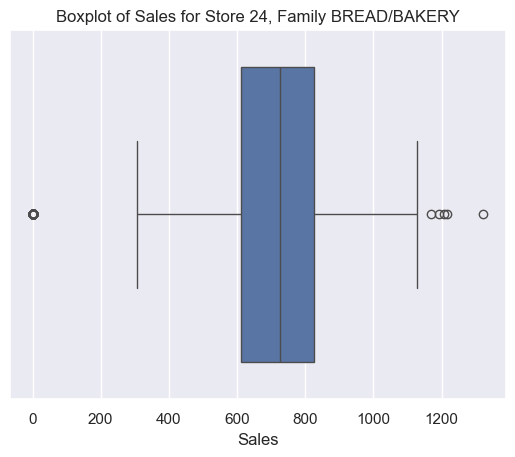

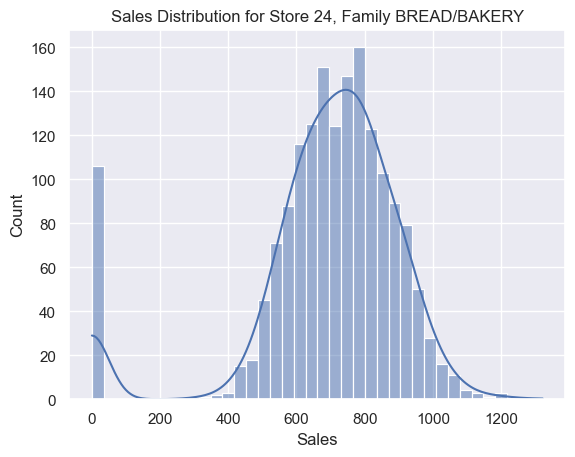


Store Number: 24, Family: CLEANING, Skewness: -1.7957010183109618, Mean Sales: 1110.2761282660333


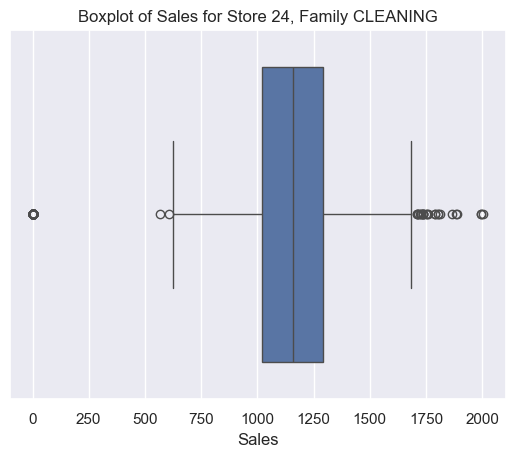

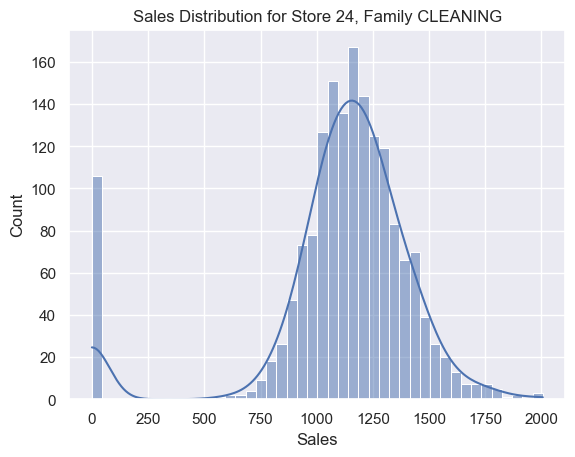


Store Number: 24, Family: DAIRY, Skewness: -0.7645985008545018, Mean Sales: 1073.127078384798


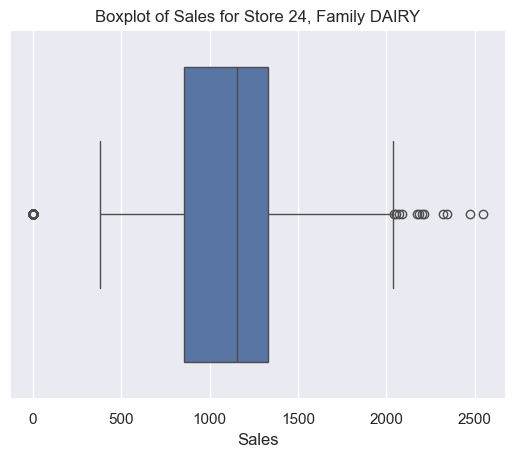

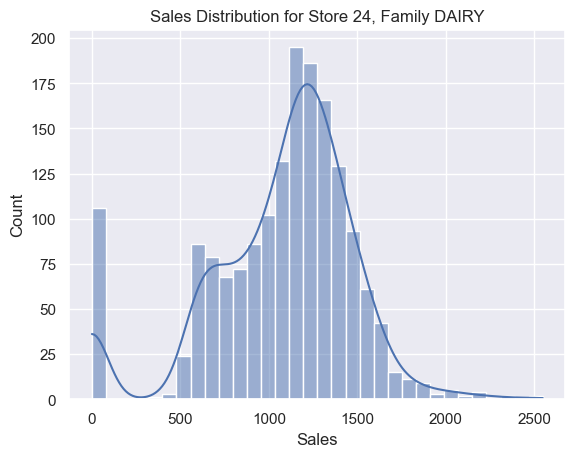


Store Number: 24, Family: DELI, Skewness: -0.8701940065016461, Mean Sales: 253.106836739905


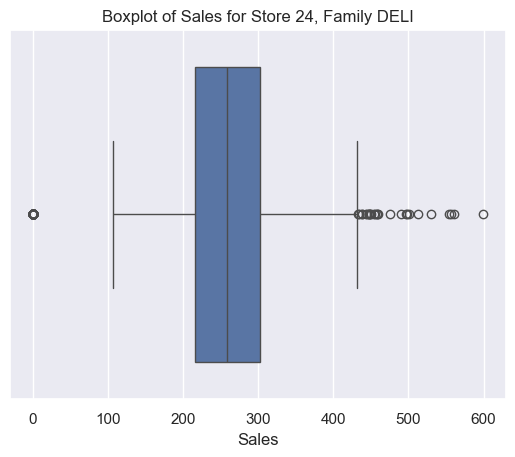

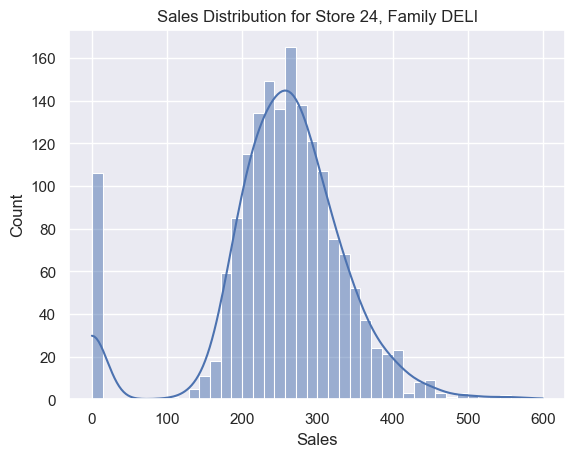


Store Number: 24, Family: EGGS, Skewness: -1.7013523893837923, Mean Sales: 204.5184085510689


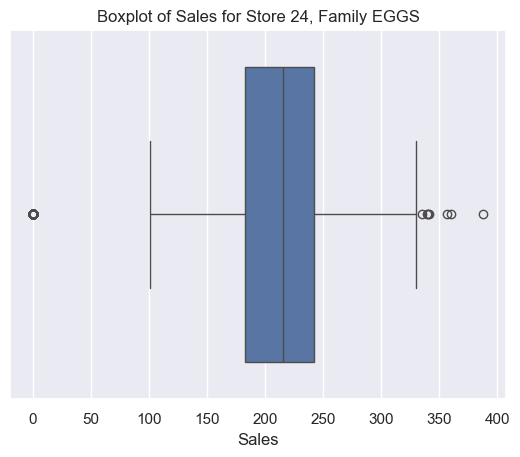

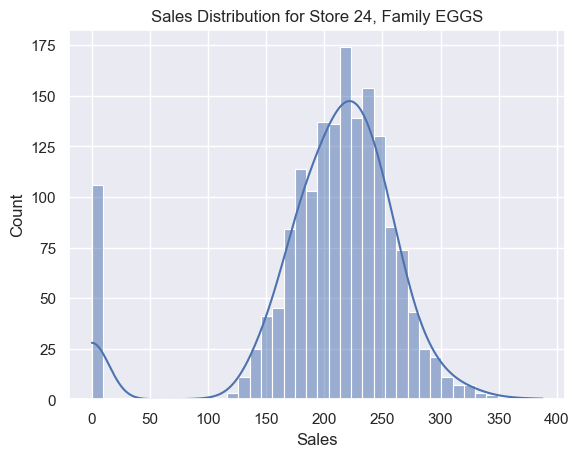


Store Number: 24, Family: HOME CARE, Skewness: -0.12870465950861376, Mean Sales: 171.5249406175772


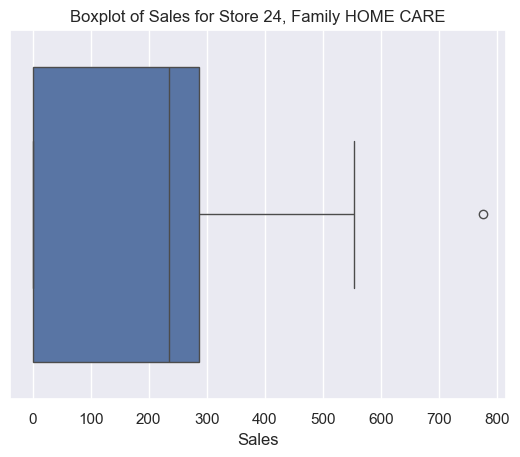

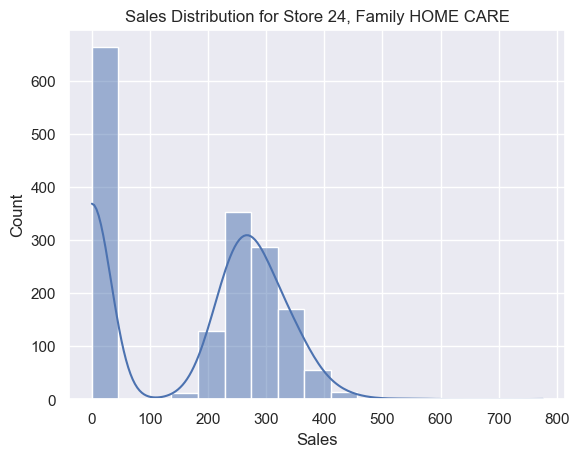


Store Number: 24, Family: MEATS, Skewness: -0.2840694541897947, Mean Sales: 387.9689158788599


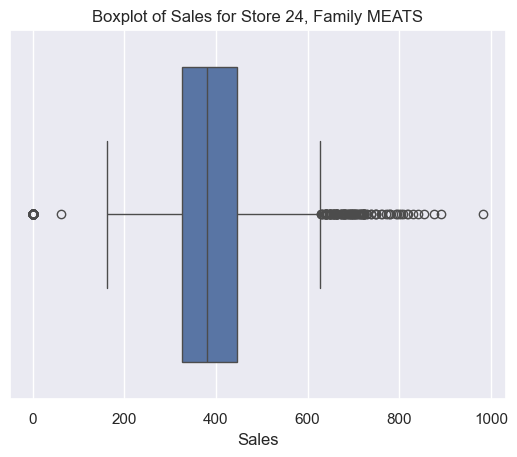

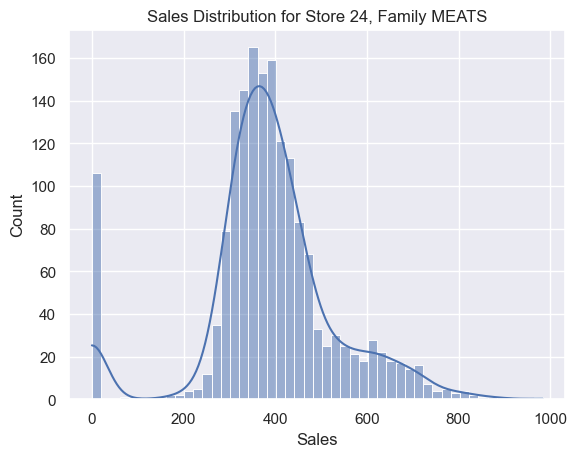


Store Number: 24, Family: PERSONAL CARE, Skewness: -0.5323603326891136, Mean Sales: 263.2874109263658


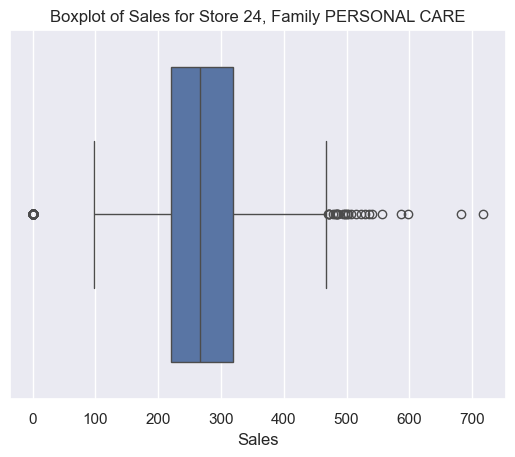

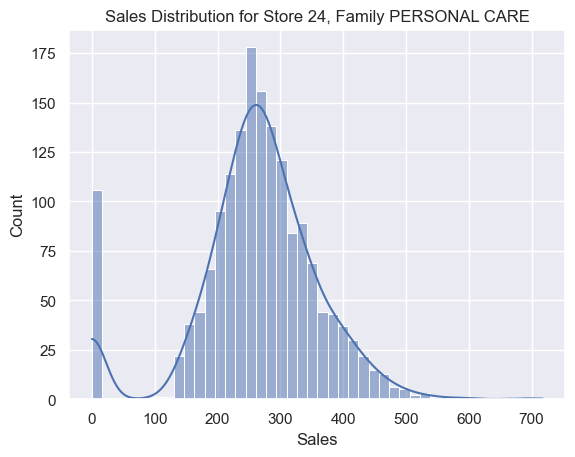


Store Number: 24, Family: POULTRY, Skewness: -0.34824238261406915, Mean Sales: 487.2632489548693


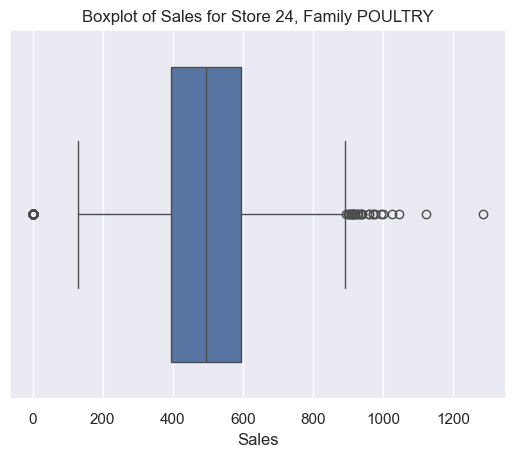

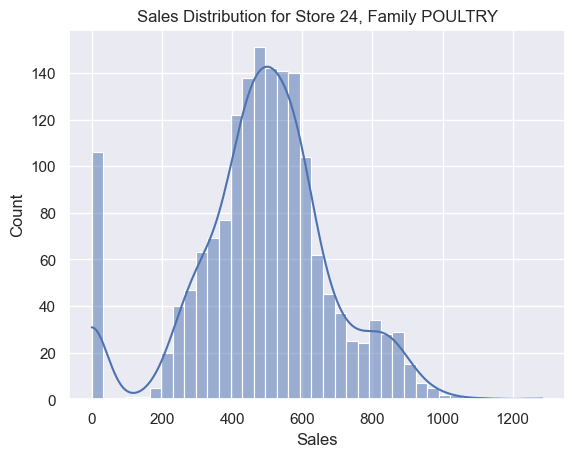


Store Number: 24, Family: PREPARED FOODS, Skewness: -1.315928434028244, Mean Sales: 129.06629098515438


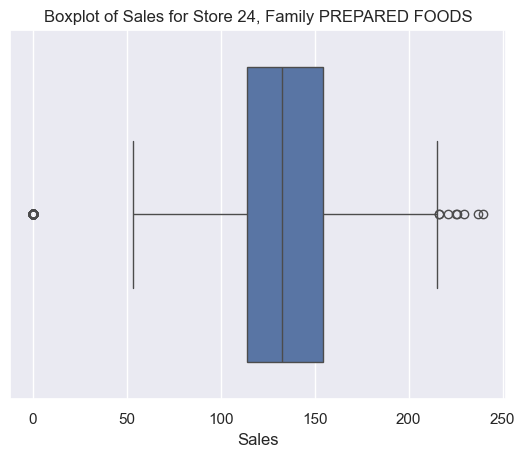

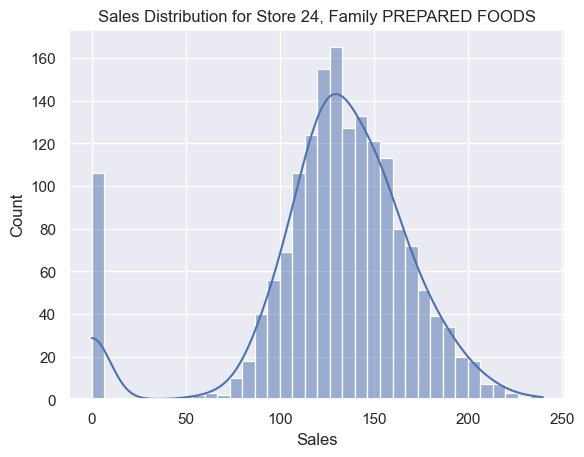


Store Number: 24, Family: SEAFOOD, Skewness: -0.0661589813341631, Mean Sales: 35.50698676068883


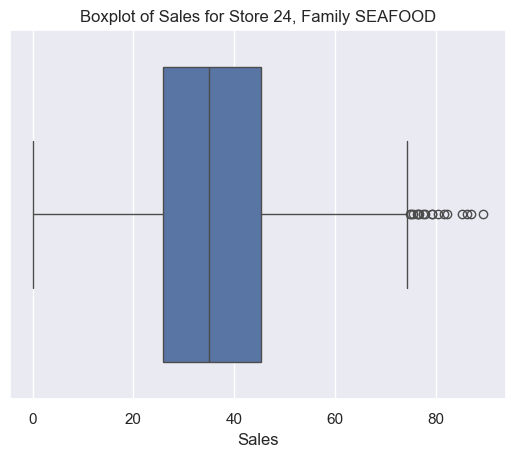

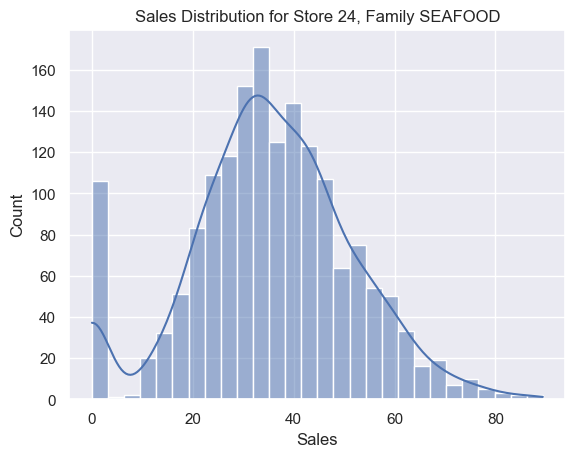


Store Number: 34, Family: DAIRY, Skewness: -0.034851852216526175, Mean Sales: 569.9614014251781


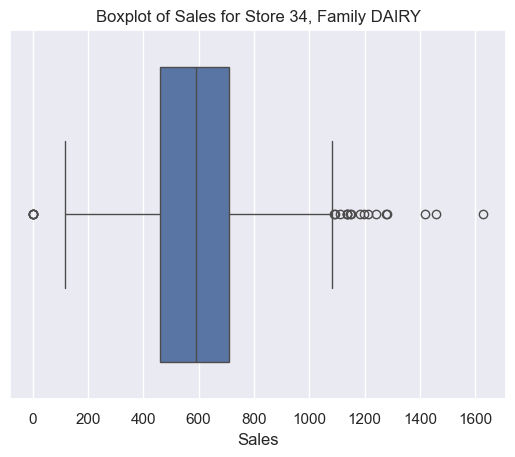

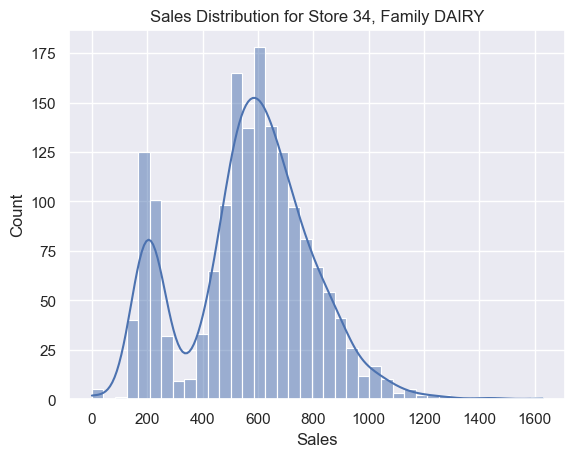


Store Number: 34, Family: HOME CARE, Skewness: -0.03656528224990632, Mean Sales: 151.0682897862233


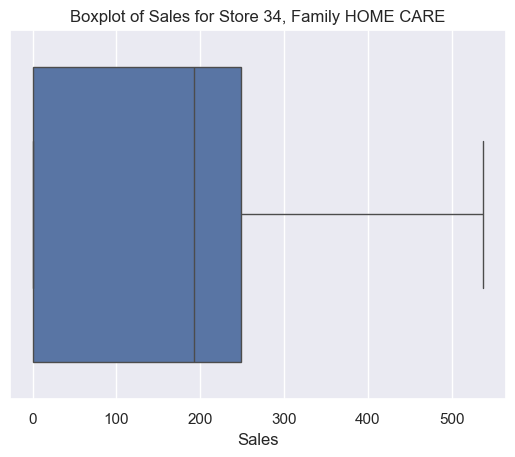

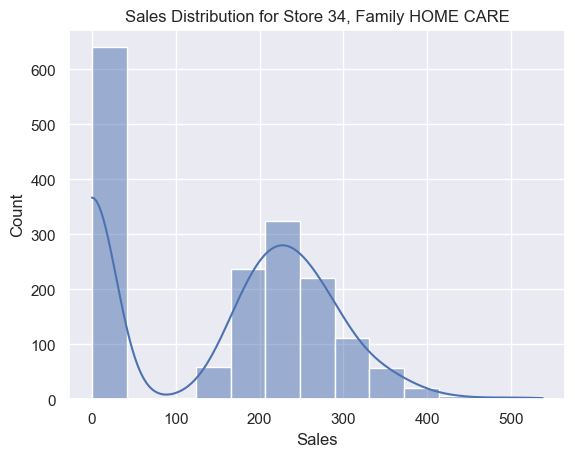


Store Number: 36, Family: BREAD/BAKERY, Skewness: -0.45975293480768326, Mean Sales: 455.67161520190024


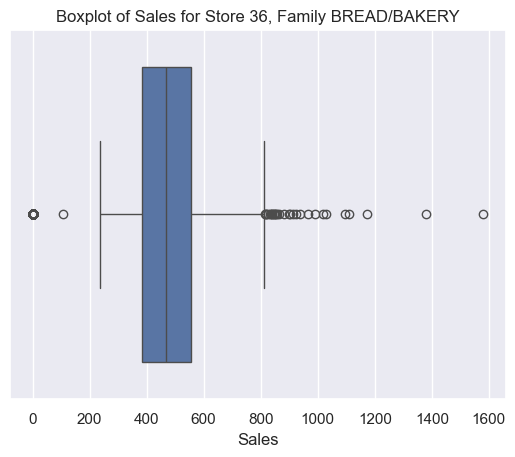

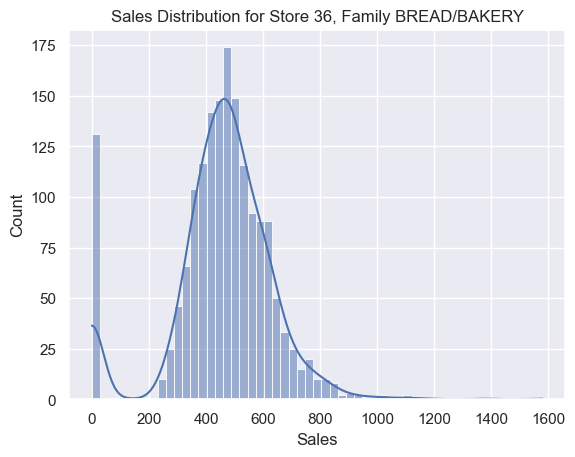


Store Number: 36, Family: CLEANING, Skewness: -0.19118300193210178, Mean Sales: 814.2755344418052


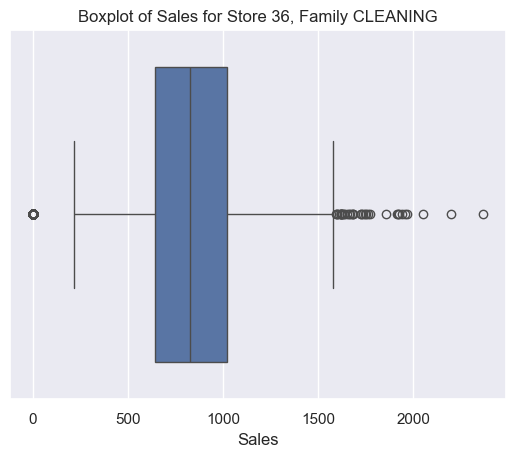

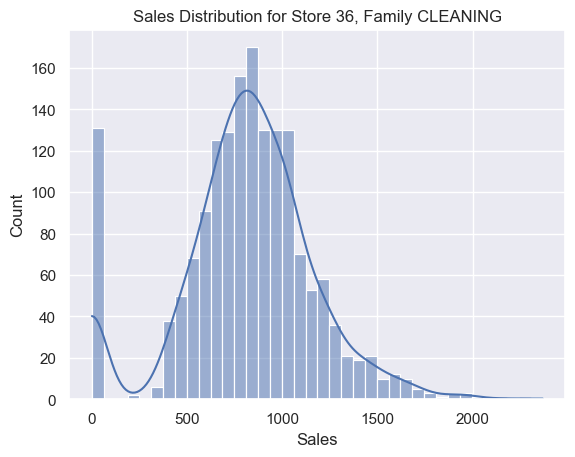


Store Number: 36, Family: DAIRY, Skewness: -0.26044595697309214, Mean Sales: 493.7304038004751


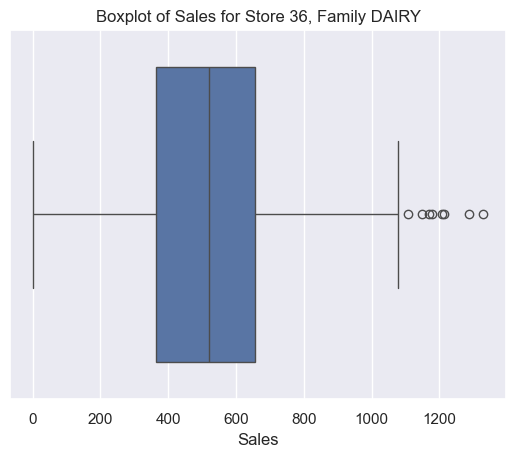

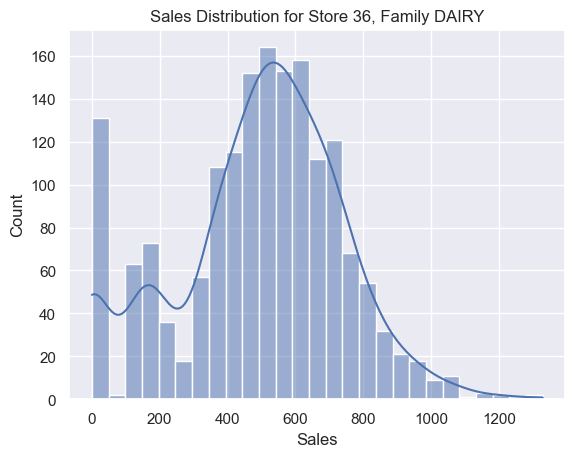


Store Number: 36, Family: DELI, Skewness: -0.12651718855739197, Mean Sales: 196.43639907719717


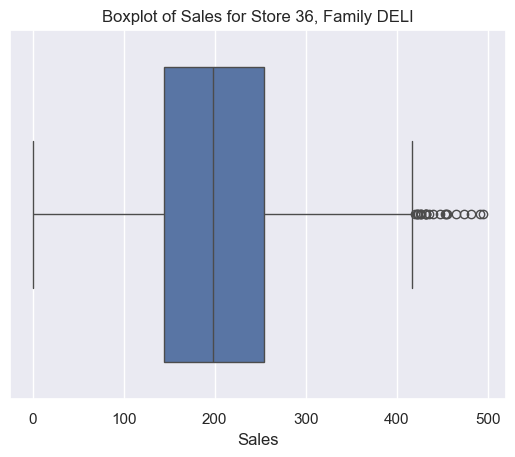

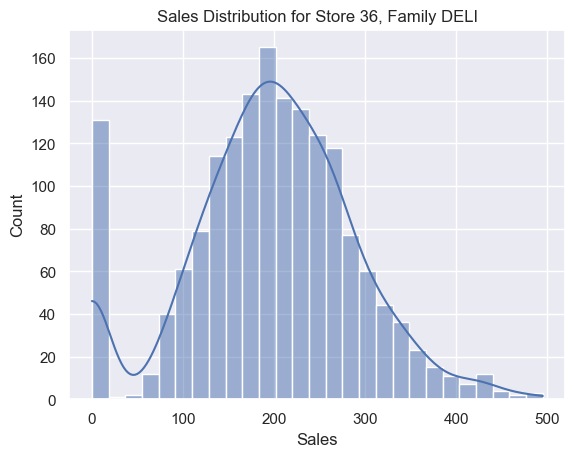


Store Number: 37, Family: BREAD/BAKERY, Skewness: -0.09388510170928106, Mean Sales: 547.5058669299287


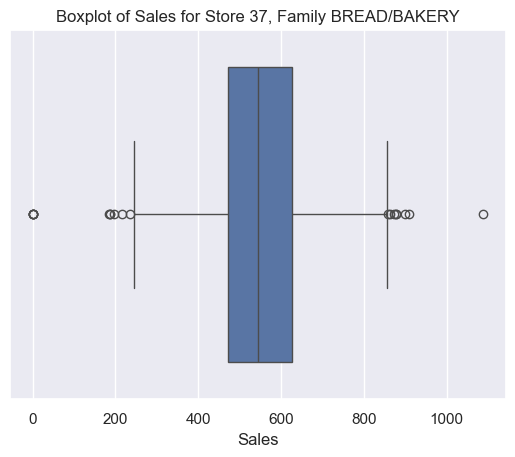

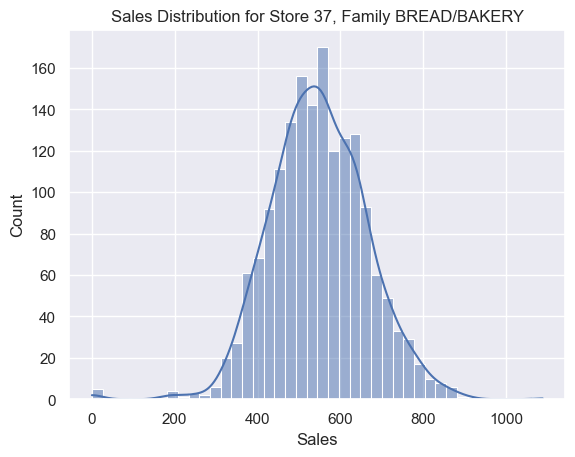


Store Number: 37, Family: DAIRY, Skewness: -0.2144503386498379, Mean Sales: 884.6692399049881


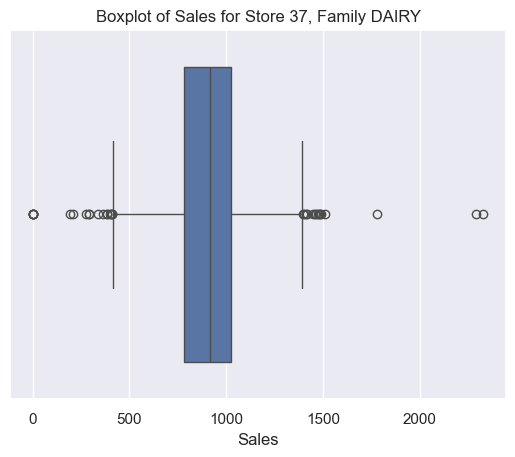

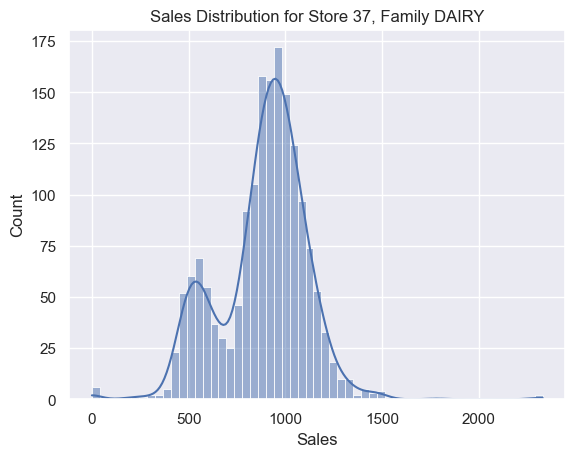


Store Number: 37, Family: HOME CARE, Skewness: -0.1044543816620864, Mean Sales: 156.60510688836104


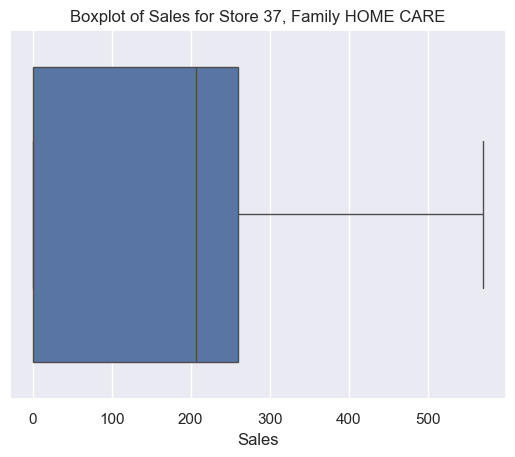

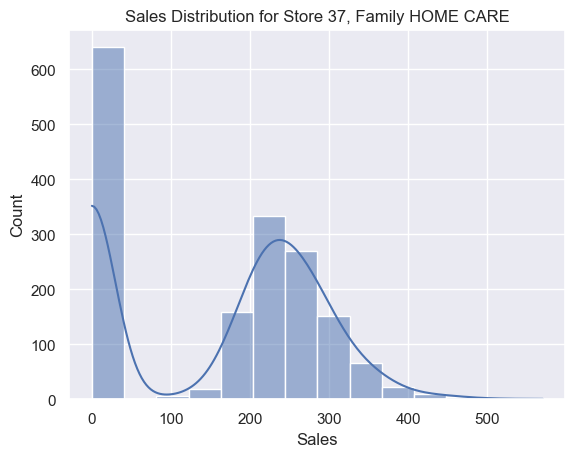


Store Number: 37, Family: POULTRY, Skewness: -0.45921535130024727, Mean Sales: 244.32092876187647


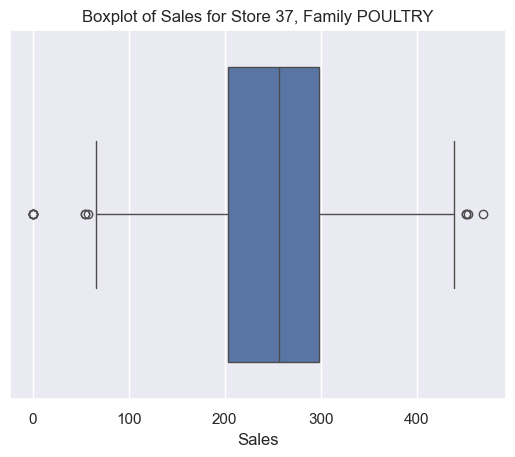

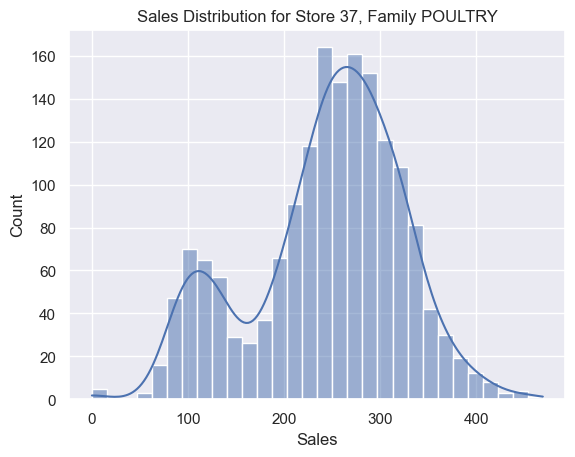


Store Number: 40, Family: DAIRY, Skewness: -0.1336248087928693, Mean Sales: 466.34619952494063


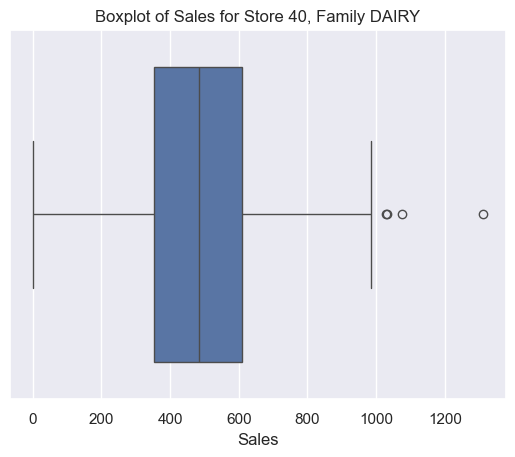

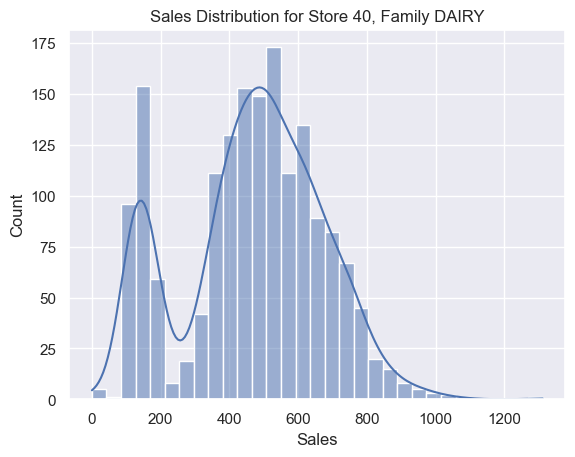


Store Number: 40, Family: MEATS, Skewness: -0.2736563009543713, Mean Sales: 112.07384544536818


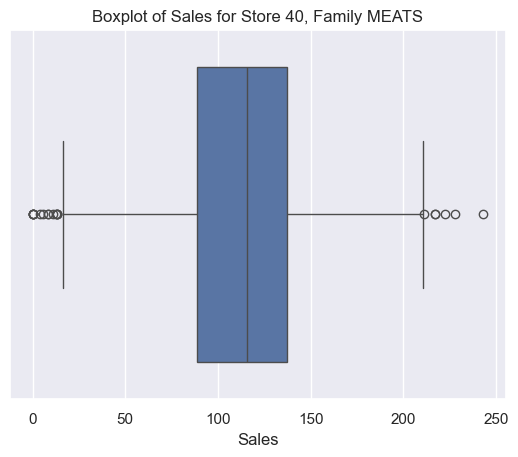

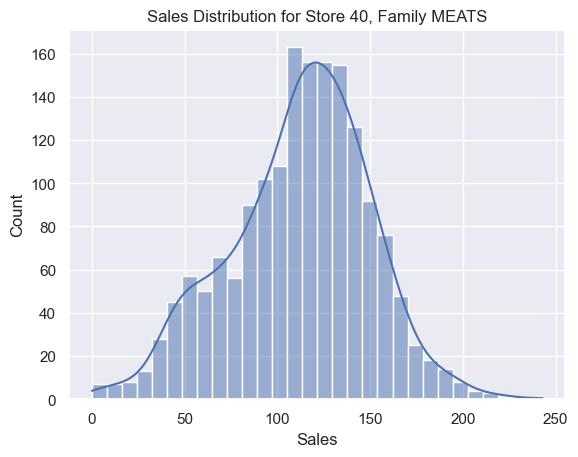


Store Number: 49, Family: POULTRY, Skewness: -0.07586824512216232, Mean Sales: 873.354301152019


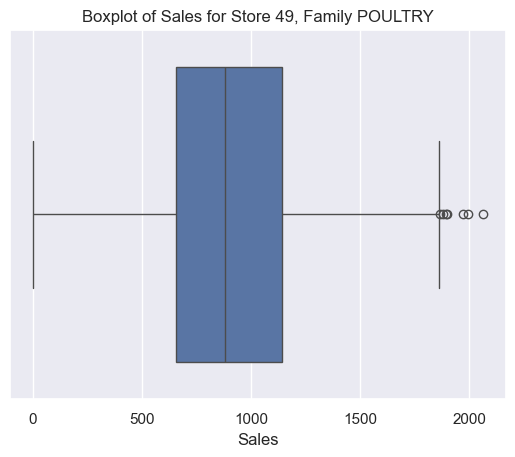

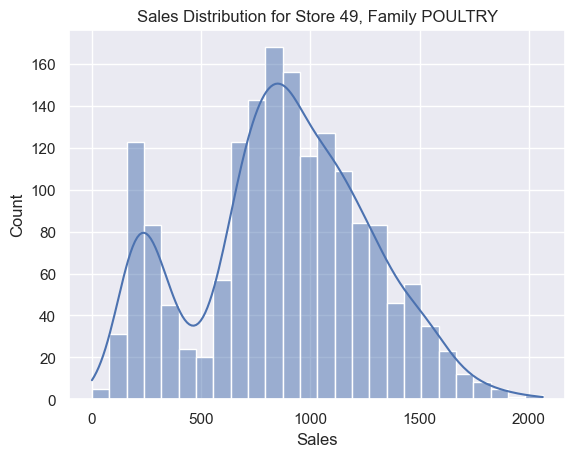


Store Number: 49, Family: PRODUCE, Skewness: -0.021257385433970467, Mean Sales: 4761.263210391924


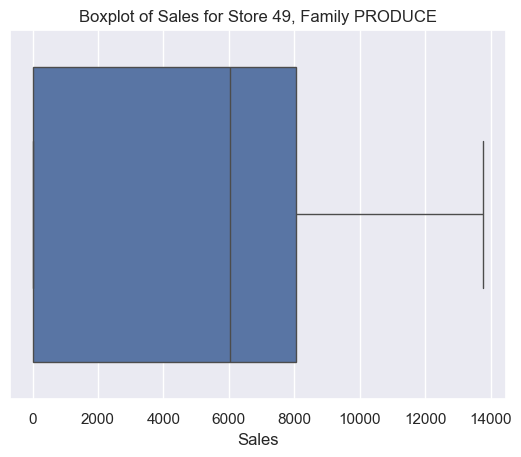

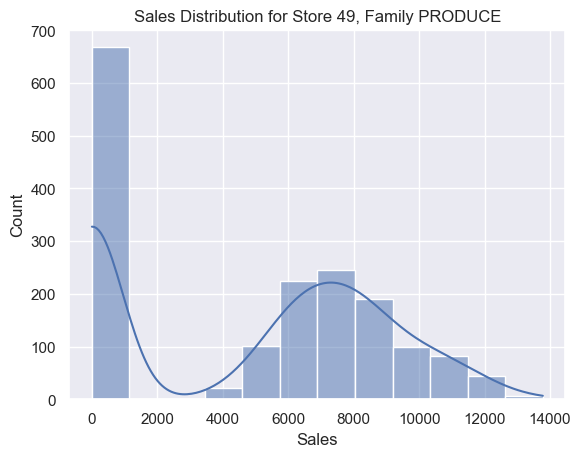


Store Number: 50, Family: PRODUCE, Skewness: -0.002016328860829641, Mean Sales: 1441.8997113420428


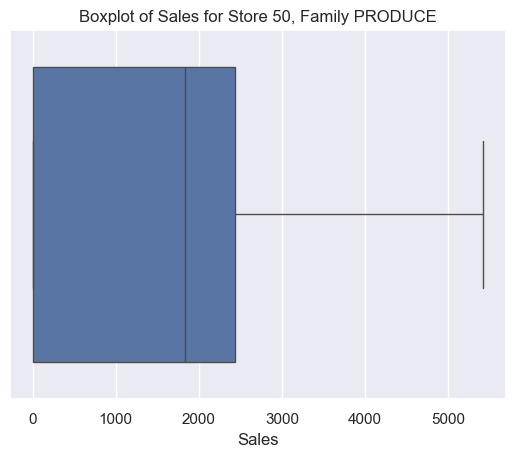

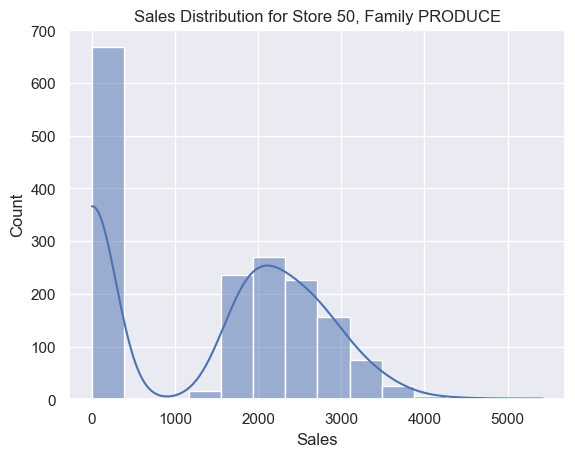

In [30]:
for index, row in left_skewed_distributions.iterrows():
    store_nbr = row['store_nbr']
    family = row['family']
    skewness = row['skew']
    mean_sales = row['mean_sales']
    print(f"\nStore Number: {store_nbr}, Family: {family}, Skewness: {skewness}, Mean Sales: {mean_sales}")
    
    df_subset = df_train[(df_train['store_nbr'] == store_nbr) & (df_train['family'] == family)]

    ax = sns.boxplot(
        data=df_subset,
        x='sales'
    )

    ax.set_title(f'Boxplot of Sales for Store {store_nbr}, Family {family}')
    ax.set_xlabel('Sales')

    plt.show()
    
    ax = sns.histplot(
        data=df_subset,
        x='sales',
        kde=True
    )
    
    ax.set_title(f'Sales Distribution for Store {store_nbr}, Family {family}')
    ax.set_xlabel('Sales')
    plt.show()

Most of the left-skewed granularities are above sales's means's Q3, which means they usually sell a lot. Let's join it with the stores data to try to find something in common between them.

In [15]:
df_stores = pd.read_csv('../data/stores.csv')

left_skewed_distributions_with_stores = left_skewed_distributions.merge(df_stores, on='store_nbr', how='left')

display(left_skewed_distributions_with_stores['city'].value_counts())
display(left_skewed_distributions_with_stores['state'].value_counts())
display(left_skewed_distributions_with_stores['type'].value_counts())
display(left_skewed_distributions_with_stores['cluster'].value_counts())

city
Quito            17
Guayaquil        13
Ambato            5
Libertad          4
Cuenca            4
Latacunga         3
Riobamba          2
Ibarra            2
Machala           2
Santo Domingo     1
Name: count, dtype: int64

state
Pichincha                         17
Guayas                            17
Tungurahua                         5
Azuay                              4
Cotopaxi                           3
Chimborazo                         2
Imbabura                           2
El Oro                             2
Santo Domingo de los Tsachilas     1
Name: count, dtype: int64

type
D    34
C     9
E     4
B     3
A     3
Name: count, dtype: int64

cluster
1     11
8      8
13     6
15     5
9      4
10     4
2      4
7      2
6      2
3      2
11     2
4      1
16     1
14     1
Name: count, dtype: int64

Most of the stores are in big cities (Quito and Guayaquil) and belong to the D cluster (the cluster groups similar stores).

Let's look at the average sales distribution for left and right-skewed distribution.

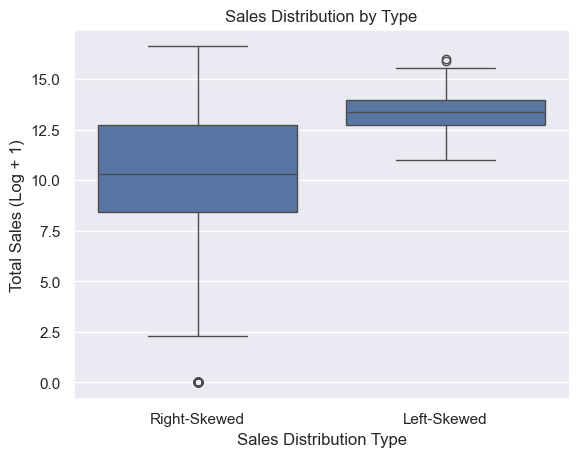

In [16]:
df_distribution_by_granularity['classification'] = df_distribution_by_granularity.apply(lambda row: 'Left-Skewed' if row['skew'] < 0 else 'Right-Skewed', axis=1)

df_distribution_by_granularity['total_sales_log'] = np.log1p(df_distribution_by_granularity['total_sales'])

ax = sns.boxplot(data=df_distribution_by_granularity, x='classification', y='total_sales_log')

ax.set_title('Sales Distribution by Type')
ax.set_xlabel('Sales Distribution Type')
ax.set_ylabel('Total Sales (Log + 1)')

plt.show()

The right-skewed's range is bigger, but it's more likely for a granularty to be left-skewed if it sells a lot.

# 3. Promotions' distribution

## 3. 1. Full distribution

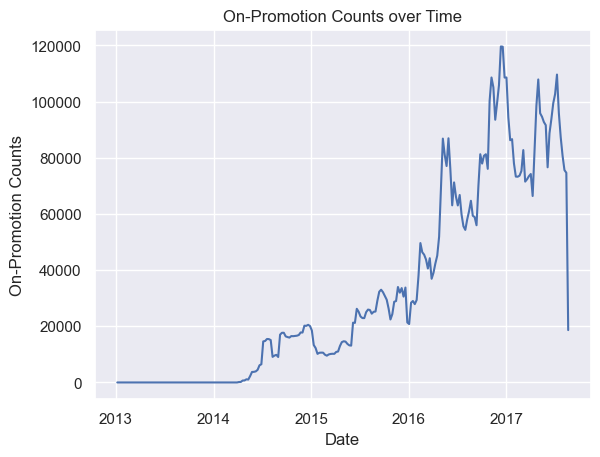

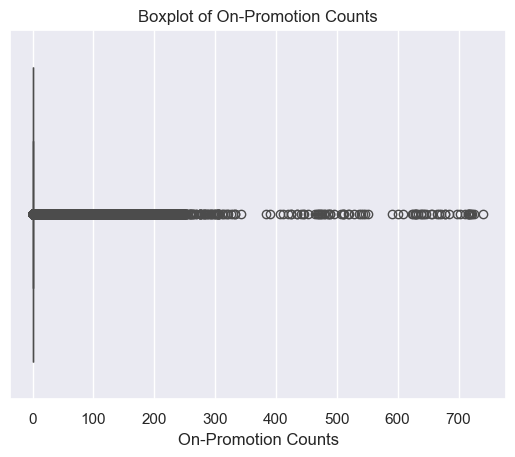

Skew: 11.166561930715051
Kurtosis: 240.87112184238433


In [31]:
ax = sns.lineplot(
    data=df_train.resample('W', on='date').sum().reset_index().sort_values(by='date'),
    x='date',
    y='onpromotion'
)

ax.set_title('On-Promotion Counts over Time')
ax.set_xlabel('Date')
ax.set_ylabel('On-Promotion Counts')
plt.show()

ax = sns.boxplot(
    data=df_train,
    x='onpromotion'
)

ax.set_title('Boxplot of On-Promotion Counts')
ax.set_xlabel('On-Promotion Counts')

plt.show()

print(f"Skew: {df_train['onpromotion'].skew()}")
print(f"Kurtosis: {df_train['onpromotion'].kurtosis()}")

The earthquake also impacted the promotions, as we can see a promotion peak.

Also very right-skewed. Let's check by granularity.

## 3. 2. Distribution by Granularity

In [36]:
df_distribution_by_granularity = (
     df_train
    .groupby(['store_nbr', 'family'])['onpromotion']
    .agg(
        skew=lambda x: skew(x),
        kurtosis=lambda x: kurtosis(x),
        total_onpromotion='sum',
        mean_onpromotion='mean'
    )
    .reset_index()
)

display(df_distribution_by_granularity.sort_values(by='skew'))

,store_nbr,family,skew,kurtosis,total_onpromotion,mean_onpromotion
1576,48,PERSONAL CARE,1.236840,0.584365,6022,3.576010
1477,45,PERSONAL CARE,1.238480,0.465963,5645,3.352138
1642,50,PERSONAL CARE,1.242377,0.421382,4912,2.916865
1609,49,PERSONAL CARE,1.247781,0.490978,5183,3.077791
1299,40,GROCERY I,1.287331,0.634134,34807,20.669240
...,...,...,...,...,...,...
1717,53,BABY CARE,NaN,NaN,0,0.000000
1720,53,BOOKS,NaN,NaN,0,0.000000
1753,54,BOOKS,NaN,NaN,0,0.000000
1768,54,LADIESWEAR,NaN,NaN,0,0.000000


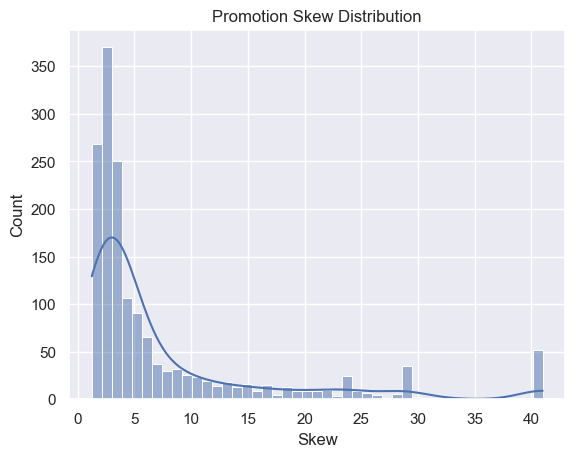

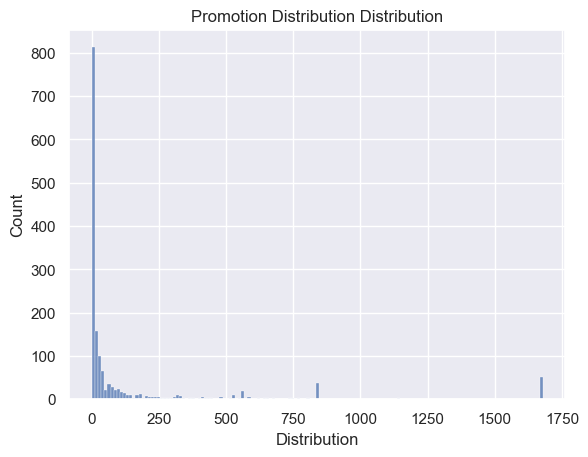

In [43]:
ax = sns.histplot(
    data=df_distribution_by_granularity,
    x='skew',
    kde=True
)

ax.set_title('Promotion Skew Distribution')
ax.set_xlabel('Skew')
ax.set_ylabel('Count')

plt.show()

ax = sns.histplot(
    data=df_distribution_by_granularity,
    x='kurtosis'
)

ax.set_title('Promotion Distribution Distribution')
ax.set_xlabel('Distribution')
ax.set_ylabel('Count')

plt.show()

Let's take a closer look at the kurtosis distribution.

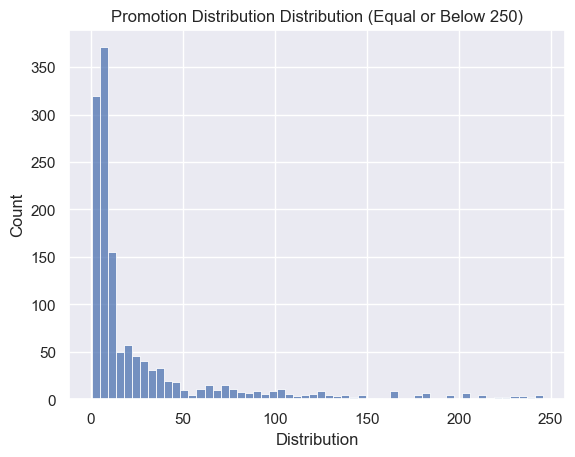

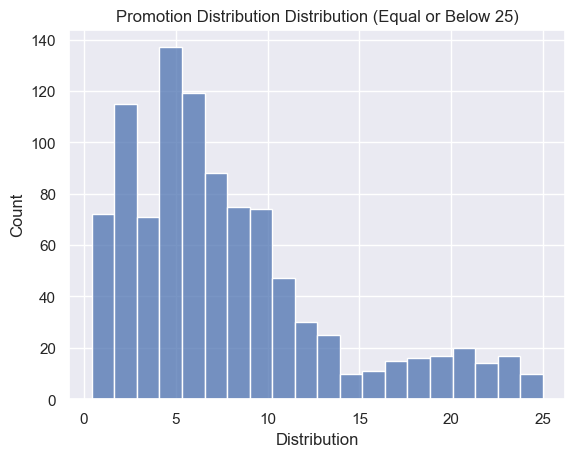

In [50]:
ax = sns.histplot(
    data=df_distribution_by_granularity[df_distribution_by_granularity['kurtosis'] <= 250],
    x='kurtosis'
)

ax.set_title('Promotion Distribution Distribution (Equal or Below 250)')
ax.set_xlabel('Distribution')
ax.set_ylabel('Count')

plt.show()

ax = sns.histplot(
    data=df_distribution_by_granularity[df_distribution_by_granularity['kurtosis'] <= 25],
    x='kurtosis'
)

ax.set_title('Promotion Distribution Distribution (Equal or Below 25)')
ax.set_xlabel('Distribution')
ax.set_ylabel('Count')

plt.show()

Overall, there seems to be higher kurtosis values, which means that the data tends to peak around a certain value. There are no left-skewed distributions, so no granularity has promotions on most part of the days.

# 4. Summary

The main findings are:
- both the sales and the promotion data have granularities with very high skew and kurtosis distributions. For thoses cases, applying some transformation like the log one may be useful to smooth the distribution;
- the sales peak caused by the April, 2016's earthquake impacted the sales and the promotion. So, it may be needed to create a dummy variable for the event (e. g., `is_earthquake`) for the rows during and after the period (e. g. from April, 16, 2016 to December, 31, 2016, where the data seem to have returned to the standard behavior).